In [1]:
!pip install stable-baselines3[extra] gymnasium torch --quiet

import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from typing import Dict, List, Optional, Tuple, Type
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device   : {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.7 MB/s eta 0:00:00


2026-05-19 13:10:39.354847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779196239.633493      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779196239.709068      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779196240.410721      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779196240.410777      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779196240.410780      57 computation_placer.cc:177] computation placer alr

✅ Imports ready
   PyTorch  : 2.10.0+cpu
   CUDA available: False
   Device   : cpu


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# ═══════════════════════════════════════════════════
# BANISTER IMPULSE-RESPONSE MODEL  (Banister, 1991)
# ═══════════════════════════════════════════════════
from dataclasses import dataclass
@dataclass
class PhysiologicalState:
    """
    8 numbers that describe an athlete's body right now.
    This is the STATE (S) in our MDP.

    Think of it as what a coach writes on a whiteboard
    before deciding next week's training plan.
    """
    atl:          float = 0.0    # Acute Training Load  = fatigue  (7-day)
    ctl:          float = 0.0    # Chronic Training Load = fitness (42-day)
    tsb:          float = 0.0    # TSB = CTL - ATL = form (positive = fresh)
    ramp_rate:    float = 0.0    # Week-over-week load change (>10% = risky)
    rpe_avg:      float = 5.0    # How hard did runs FEEL? (1=easy, 10=max)
    compliance:   float = 1.0    # Did athlete complete the plan? (0 to 1)
    injury_flag:  int   = 0      # 1 if injured this week
    days_to_race: int   = 84     # Countdown to race day

    def to_array(self) -> np.ndarray:
        """RL agents only understand numbers, not objects."""
        return np.array([
            self.atl, self.ctl, self.tsb, self.ramp_rate,
            self.rpe_avg, self.compliance,
            float(self.injury_flag), self.days_to_race,
        ], dtype=np.float32)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> "PhysiologicalState":
        return cls(
            atl=float(arr[0]),     ctl=float(arr[1]),
            tsb=float(arr[2]),     ramp_rate=float(arr[3]),
            rpe_avg=float(arr[4]), compliance=float(arr[5]),
            injury_flag=int(arr[6]), days_to_race=int(arr[7]),
        )

    def __repr__(self):
        return (f"State(ATL={self.atl:.1f}, CTL={self.ctl:.1f}, "
                f"TSB={self.tsb:+.1f}, RPE={self.rpe_avg:.1f}, "
                f"compliance={self.compliance:.0%}, "
                f"injured={bool(self.injury_flag)}, "
                f"race_in={self.days_to_race}d)")


class BannisterModel:
    """
    EWMA-based Banister model.

    Core equations:
        ATL = ATL + k_atl * (TRIMP - ATL)   k_atl = 1 - exp(-1/7)  ≈ 0.133
        CTL = CTL + k_ctl * (TRIMP - CTL)   k_ctl = 1 - exp(-1/42) ≈ 0.023

    Why EWMA over rolling averages?
    More weight to recent training — matches real physiology. (Hulin 2016)
    """
    TAU_ATL, TAU_CTL = 7, 42

    def __init__(self):
        self.k_atl = 1 - np.exp(-1 / self.TAU_ATL)
        self.k_ctl = 1 - np.exp(-1 / self.TAU_CTL)
        self.atl = self.ctl = 0.0

    def reset(self, initial_ctl: float = 0.0, initial_atl: float = 0.0):
        self.atl, self.ctl = initial_atl, initial_ctl

    def update_day(self, trimp: float):
        """Apply one day's training load."""
        self.atl = self.atl + self.k_atl * (trimp - self.atl)
        self.ctl = self.ctl + self.k_ctl * (trimp - self.ctl)

    def update_week(self, daily_trimp: List[float]) -> PhysiologicalState:
        """Apply 7 days of training. Returns state at end of week."""
        assert len(daily_trimp) == 7, "Need exactly 7 days"
        atl_start = self.atl
        for t in daily_trimp:
            self.update_day(t)
        ramp_rate = (self.atl - atl_start) / (atl_start + 1e-6)
        return PhysiologicalState(
            atl=self.atl, ctl=self.ctl,
            tsb=self.ctl - self.atl, ramp_rate=ramp_rate,
        )

    @property
    def tsb(self) -> float:
        return self.ctl - self.atl

    @property
    def acwr(self) -> float:
        """
        Acute:Chronic Workload Ratio. Safe zone: 0.8 - 1.3
        ⚠️  Used as ONE of 4 injury signals — NOT the sole predictor.
        (Impellizzeri et al., 2020 — ACWR alone is insufficient)
        """
        return self.atl / (self.ctl + 1e-6)

    def get_tsb_zone(self) -> str:
        tsb = self.tsb
        if tsb > 25:     return "PEAK"
        elif tsb > 5:    return "FRESH"
        elif tsb > -10:  return "OPTIMAL"
        elif tsb > -30:  return "FATIGUED"
        else:            return "OVERREACHED"


def compute_trimp(duration_min: float,
                  avg_hr: Optional[float] = None,
                  rpe: Optional[float] = None,
                  hr_max: float = 185.0,
                  hr_rest: float = 58.0) -> float:
    """
    TRIMP = Training Impulse. One number per session.

    Method 1 — HR-based (Banister 1991):
        TRIMP = duration × HRR × 0.64 × e^(1.92 × HRR)
    Method 2 — RPE-based (Foster 2001):
        TRIMP = RPE × duration × 0.8   (no HR monitor needed)
    """
    if avg_hr is not None:
        hrr = np.clip((avg_hr - hr_rest) / (hr_max - hr_rest + 1e-6), 0, 1)
        return float(duration_min * hrr * 0.64 * np.exp(1.92 * hrr))
    elif rpe is not None:
        return float(rpe * duration_min * 0.8)
    raise ValueError("Provide avg_hr or rpe")


# ── Quick sanity check ────────────────────────────────────────────
print("✅ BannisterModel ready")
print(f"   k_atl = {1 - np.exp(-1/7):.4f}  (fatigue decay rate)")
print(f"   k_ctl = {1 - np.exp(-1/42):.4f}  (fitness decay rate)")
print()

m = BannisterModel()
m.reset(initial_ctl=40, initial_atl=35)
print(f"Initial  → ATL:{m.atl:.0f}  CTL:{m.ctl:.0f}  TSB:{m.tsb:+.0f}  Zone:{m.get_tsb_zone()}")
m.update_week([80, 0, 90, 0, 70, 0, 100])
print(f"Hard wk  → ATL:{m.atl:.1f}  CTL:{m.ctl:.1f}  TSB:{m.tsb:+.1f}  Zone:{m.get_tsb_zone()}")
m.update_week([0]*7)
print(f"Rest wk  → ATL:{m.atl:.1f}  CTL:{m.ctl:.1f}  TSB:{m.tsb:+.1f}  Zone:{m.get_tsb_zone()}")

✅ BannisterModel ready
   k_atl = 0.1331  (fatigue decay rate)
   k_ctl = 0.0235  (fitness decay rate)

Initial  → ATL:35  CTL:40  TSB:+5  Zone:OPTIMAL
Hard wk  → ATL:44.5  CTL:41.3  TSB:-3.1  Zone:OPTIMAL
Rest wk  → ATL:16.4  CTL:35.0  TSB:+18.6  Zone:FRESH


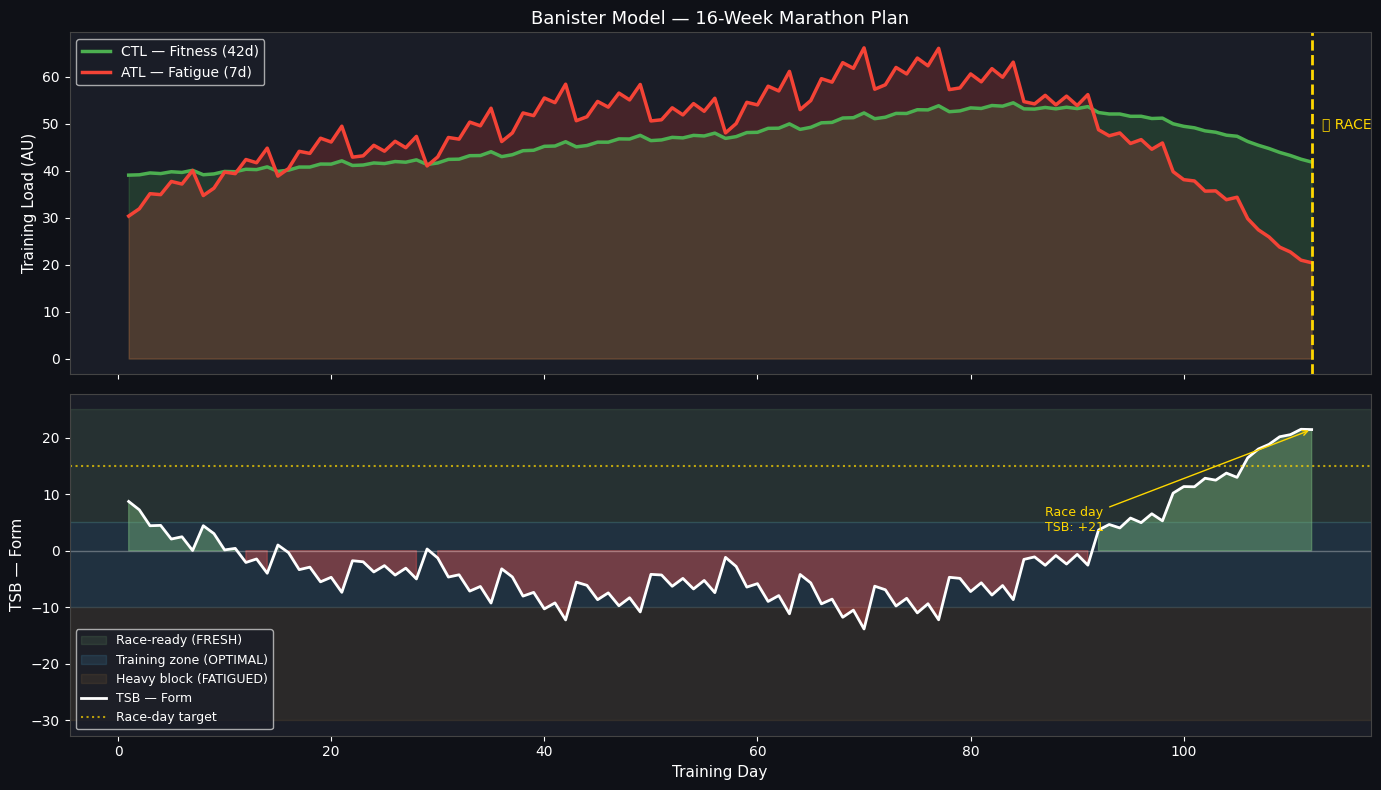


📊 Race day state:
   CTL (Fitness) : 41.8
   ATL (Fatigue) : 20.4
   TSB (Form)    : +21.4  ← target is +5 to +25


In [3]:
# ── Simulate 16-week marathon plan ───────────────────────────────

def simulate_plan(weekly_loads, initial_ctl=40.0, initial_atl=35.0):
    model = BannisterModel()
    model.reset(initial_ctl=initial_ctl, initial_atl=initial_atl)
    days, atls, ctls, tsbs = [], [], [], []
    for week_idx, weekly_trimp in enumerate(weekly_loads):
        fracs = np.array([0.0, 0.15, 0.20, 0.12, 0.20, 0.12, 0.21])
        daily = (fracs * weekly_trimp).tolist()
        for day_idx, trimp in enumerate(daily):
            model.update_day(trimp)
            days.append(week_idx * 7 + day_idx + 1)
            atls.append(model.atl)
            ctls.append(model.ctl)
            tsbs.append(model.tsb)
    return days, atls, ctls, tsbs

# Build → Peak → Taper (classic marathon plan)
weekly_trimp = [
    280, 310, 340, 300,   # Weeks 1-4:  Base build
    370, 400, 380, 350,   # Weeks 5-8:  Progressive build
    420, 450, 430, 400,   # Weeks 9-12: Peak block
    340, 260, 180,  80,   # Weeks 13-16: Taper → Race
]

days, atls, ctls, tsbs = simulate_plan(weekly_trimp)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#0f1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')

# Panel 1: CTL and ATL
ax1.fill_between(days, ctls, alpha=0.2, color='#4CAF50')
ax1.fill_between(days, atls, alpha=0.2, color='#f44336')
ax1.plot(days, ctls, color='#4CAF50', linewidth=2.5, label='CTL — Fitness (42d)')
ax1.plot(days, atls, color='#f44336', linewidth=2.5, label='ATL — Fatigue (7d)')
ax1.set_ylabel('Training Load (AU)', color='white', fontsize=11)
ax1.legend(facecolor='#1a1d27', labelcolor='white', fontsize=10)
ax1.set_title('Banister Model — 16-Week Marathon Plan',
               color='white', fontsize=13)
ax1.axvline(x=112, color='gold', linewidth=2, linestyle='--')
ax1.text(113, max(ctls)*0.9, '🏁 RACE', color='gold', fontsize=10)

# Panel 2: TSB (Form)
tsbs_arr = np.array(tsbs)
ax2.axhline(y=0, color='white', alpha=0.3, linewidth=1)
ax2.axhspan( 5,  25, alpha=0.12, color='#81c784', label='Race-ready (FRESH)')
ax2.axhspan(-10,  5, alpha=0.12, color='#4fc3f7', label='Training zone (OPTIMAL)')
ax2.axhspan(-30,-10, alpha=0.08, color='#ffb74d', label='Heavy block (FATIGUED)')
ax2.fill_between(days, tsbs_arr, 0, where=(tsbs_arr >= 0), alpha=0.4, color='#81c784')
ax2.fill_between(days, tsbs_arr, 0, where=(tsbs_arr <  0), alpha=0.4, color='#ef5350')
ax2.plot(days, tsbs_arr, color='white', linewidth=2, label='TSB — Form')
ax2.axhline(y=15, color='gold', linestyle=':', alpha=0.7, label='Race-day target')
ax2.set_ylabel('TSB — Form', color='white', fontsize=11)
ax2.set_xlabel('Training Day', color='white', fontsize=11)
ax2.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Annotate race day
ax2.annotate(f'Race day\nTSB: {tsbs_arr[-1]:+.0f}',
             xy=(days[-1], tsbs_arr[-1]),
             xytext=(days[-1]-25, tsbs_arr[-1]-18),
             color='gold', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gold'))

plt.tight_layout()
plt.show()

print(f"\n📊 Race day state:")
print(f"   CTL (Fitness) : {ctls[-1]:.1f}")
print(f"   ATL (Fatigue) : {atls[-1]:.1f}")
print(f"   TSB (Form)    : {tsbs[-1]:+.1f}  ← target is +5 to +25")

In [4]:
# ═══════════════════════════════════════════════════
# ATHLETE PROFILE + SIMULATOR  (v3 — updated)
# ═══════════════════════════════════════════════════
from dataclasses import dataclass

@dataclass
class AthleteProfile:
    initial_ctl:           float = 40.0
    initial_atl:           float = 35.0
    hr_max:                float = 185.0
    hr_rest:               float = 58.0
    max_weekly_km:         float = 80.0
    min_weekly_km:         float = 15.0
    injury_susceptibility: float = 0.4
    base_compliance:       float = 0.85
    days_to_race:          int   = 84

    @classmethod
    def beginner(cls):
        return cls(initial_ctl=20.0, initial_atl=15.0,
                   min_weekly_km=20.0,
                   max_weekly_km=50.0, base_compliance=0.75,
                   injury_susceptibility=0.6)
    @classmethod
    def intermediate(cls):
        return cls(initial_ctl=40.0, initial_atl=35.0,
                   min_weekly_km=35.0,
                   max_weekly_km=80.0, base_compliance=0.85,
                   injury_susceptibility=0.4)
    @classmethod
    def advanced(cls):
        return cls(initial_ctl=65.0, initial_atl=55.0,
                   min_weekly_km=50.0,
                   max_weekly_km=120.0, base_compliance=0.90,
                   injury_susceptibility=0.25)


class AthleteSimulator:

    def __init__(self, profile: AthleteProfile, seed=None):
        self.profile  = profile
        self.rng      = np.random.default_rng(seed)
        self.banister = BannisterModel()
        self._week    = 0
        self._injured = False
        self._injury_weeks_left = 0
        self._rpe_history       = [5.0] * 7
        self._volume_history = [50.0] * 4
        self._intensity_history = [0.9] * 4   # ← NEW

    def reset(self) -> PhysiologicalState:
        self.banister.reset(self.profile.initial_ctl, self.profile.initial_atl)
        self._week              = 0
        self._injured           = False
        self._injury_weeks_left = 0
        self._rpe_history       = [5.0] * 7
        self._intensity_history = [0.9] * 4   # ← NEW
        self._volume_history = [50.0] * 4
        
        return PhysiologicalState(
            atl=self.profile.initial_atl,
            ctl=self.profile.initial_ctl,
            tsb=self.profile.initial_ctl - self.profile.initial_atl,
            days_to_race=self.profile.days_to_race,
        )

    def step(self, intensity, volume_km, workout_dist):
        self._week += 1
        volume_km    = np.clip(volume_km, self.profile.min_weekly_km,
                               self.profile.max_weekly_km)
        intensity    = np.clip(intensity, 0.75, 1.4)   # ← raised floor
        workout_dist = np.clip(workout_dist, 0.1, 1.0)

        self._intensity_history.append(intensity)      # ← NEW
        self._intensity_history = self._intensity_history[-4:]
        self._volume_history.append(volume_km)
        self._volume_history = self._volume_history[-4:]


        compliance       = self._simulate_compliance(intensity, volume_km)
        actual_volume    = volume_km * compliance
        effective_volume = actual_volume * (0.5 + 0.5 * compliance)
        daily_km         = self._distribute_volume(effective_volume, workout_dist)
        daily_trimp      = self._to_trimp(daily_km, intensity)
        b_state          = self.banister.update_week(daily_trimp)
        rpe              = self._simulate_rpe(intensity)
        self._rpe_history.append(rpe)
        self._rpe_history = self._rpe_history[-7:]

        injury_prob = self._injury_probability(b_state, rpe)
        injury      = bool(self.rng.random() < injury_prob)

        if injury:
            self._injured = True
            self._injury_weeks_left = int(self.rng.integers(2, 6))
        if self._injured:
            self._injury_weeks_left -= 1
            if self._injury_weeks_left <= 0:
                self._injured = False
            actual_volume = rpe = compliance = 0.0
            injury = True

        days_left  = max(0, self.profile.days_to_race - self._week * 7)
        next_state = PhysiologicalState(
            atl=b_state.atl, ctl=b_state.ctl, tsb=b_state.tsb,
            ramp_rate=b_state.ramp_rate, rpe_avg=rpe,
            compliance=compliance, injury_flag=int(injury),
            days_to_race=days_left,
        )
        reward = self._compute_reward(next_state, injury, compliance,
                               intensity, volume_km, workout_dist)
        done   = days_left <= 0
        info   = {
            "week": self._week, "planned_km": volume_km,
            "actual_km": actual_volume, "compliance": compliance,
            "injury": injury, "injury_prob": injury_prob,
            "acwr": self.banister.acwr,
            "tsb_zone": self.banister.get_tsb_zone(),
        }
        return next_state, reward, done, info

    def _simulate_compliance(self, intensity, volume_km):
        base    = self.profile.base_compliance
        tsb_pen = max(0, (abs(min(self.banister.tsb, 0)) - 20) * 0.005)
        int_pen = max(0, (intensity - 1.1) * 0.2)
        vol_pen = max(0, (volume_km / self.profile.max_weekly_km - 0.8) * 0.3)
        c = base - tsb_pen - int_pen - vol_pen + self.rng.normal(0, 0.05)
        return float(np.clip(c, 0.0, 1.0))

    def _distribute_volume(self, total_km, dist):
        easy  = np.array([0.0, 0.15, 0.12, 0.20, 0.12, 0.15, 0.26])
        speed = np.array([0.0, 0.18, 0.10, 0.22, 0.08, 0.22, 0.20])
        fracs = (1 - dist) * easy + dist * speed
        fracs = np.clip(fracs + self.rng.normal(0, 0.01, 7), 0, None)
        fracs /= fracs.sum()
        return (fracs * total_km).tolist()

    def _to_trimp(self, daily_km, intensity):
        effort = 0.65 + (intensity - 0.6) * 0.3
        avg_hr = self.profile.hr_rest + effort * (
            self.profile.hr_max - self.profile.hr_rest)
        result = []
        for km in daily_km:
            if km < 0.5:
                result.append(0.0)
            else:
                pace = 6.5 - (intensity - 0.6) * 2.5
                t = compute_trimp(km * pace, avg_hr=avg_hr,
                                  hr_max=self.profile.hr_max,
                                  hr_rest=self.profile.hr_rest)
                result.append(max(0.0, t * float(self.rng.normal(1.0, 0.05))))
        return result

    def _simulate_rpe(self, intensity):
        base    = 3.0 + (intensity - 0.6) * 5.0
        fatigue = max(0, (self.banister.atl - 50) * 0.02)
        return float(np.clip(base + fatigue + self.rng.normal(0, 0.3), 1, 10))

    def _injury_probability(self, state, rpe):
        acwr = self.banister.acwr
        s1 = max(0, (acwr - 1.5) * 0.08)
        s2 = max(0, (abs(state.ramp_rate) - 0.10) * 0.15)
        s3 = sum(1 for r in self._rpe_history if r > 7.5) * 0.01
        s4 = max(0, abs(state.tsb + 35) * 0.002) if state.tsb < -35 else 0
        total = (0.01 + s1 + s2 + s3 + s4) * (
            0.5 + self.profile.injury_susceptibility)
        return float(np.clip(total, 0, 0.5))
        
    def _compute_reward(self, state, injury, compliance, 
                    intensity, volume_km, workout_dist):
        
        total_weeks = self.profile.days_to_race // 7
        taper_start = total_weeks - 2
    
        # ── 1. TSB Performance ────────────────────────────────────────
        if self._week >= taper_start:
            tsb_target = 15.0
        else:
            prog = self._week / max(taper_start, 1)
            tsb_target = -15.0 + prog * 20.0
        perf = -abs(state.tsb - tsb_target) / 20.0
    
        # ── 2. Sustainable Fitness ────────────────────────────────────
        sustainable_ctl = state.ctl * compliance
        fitness = min(sustainable_ctl / 80.0, 1.0) * 0.6
        
    
        # ── 3. CTL Growth Bonus ← NEW ─────────────────────────────────
        # Explicitly reward building fitness above starting CTL
        # This is what was missing — no direct signal to grow CTL
        ctl_growth   = state.ctl - self.profile.initial_ctl
        growth_bonus = np.clip(ctl_growth / 20.0, -0.5, 1.0) * 0.8

        week_fraction = self._week / total_weeks
        if week_fraction <= 0.25:       # base phase: weeks 1-3
            vol_target_pct = 0.55
        elif week_fraction <= 0.70:     # build phase: weeks 4-8
            vol_target_pct = 0.72
        elif week_fraction <= 0.85:     # peak phase: weeks 9-10
            vol_target_pct = 0.82
        else:                           # taper: weeks 11-12
            vol_target_pct = 0.45
            
        vol_target = vol_target_pct * self.profile.max_weekly_km
        vol_error  = abs(volume_km - vol_target) / self.profile.max_weekly_km
        vol_target_reward = -vol_error * 1.5
    
        # ── 4. TSB Zone Bonus ─────────────────────────────────────────
        zone_rewards = {"OPTIMAL": 0.5, "FRESH": 0.3,
                        "FATIGUED": -0.2, "OVERREACHED": -1.0, "PEAK": 0.4}
        zone_bonus = zone_rewards.get(self.banister.get_tsb_zone(), 0.0)
    
        # ── 5. Action Variety Bonus ← EXPANDED ────────────────────────
        # Penalise being stuck at action boundaries for 3+ weeks
        intensity_std = np.std(self._intensity_history)
        volume_std    = np.std(self._volume_history)
        variety_bonus = (min(intensity_std * 2.0, 0.4) + min(volume_std / 10.0, 0.4)) # rewards varying both
    
        # ── 6. Incoherence Penalty ────────────────────────────────────
        incoherence_pen = 0.0
        if workout_dist > 0.6 and intensity < 0.85:
            incoherence_pen = -1.0 * (workout_dist - 0.6) * (0.85 - intensity) * 10
    
        # ── 7. Race Week Bonus ────────────────────────────────────────
        race_bonus = 0.0
        if self._week == total_weeks:
            race_bonus = 3.0 if 5 <= state.tsb <= 25 else -2.0
    
        # ── 8. Safety ─────────────────────────────────────────────────
        inj_pen  = -8.0 if injury else 0.0
        acwr     = self.banister.acwr
        acwr_pen = -1.5 * (acwr - 1.5) if acwr > 1.5 else (
                   -0.5 if acwr < 0.6 else 0.0)
        ramp_pen = (-2.0 * (state.ramp_rate - 0.10) if state.ramp_rate > 0.10
                    else -0.3 if state.ramp_rate > 0.05 else 0.0)
    
        # ── 9. Adherence ──────────────────────────────────────────────
        adhere = compliance * 1.0
    
        return float(perf + fitness + growth_bonus + zone_bonus + vol_target_reward +
                     variety_bonus + incoherence_pen + race_bonus +
                     inj_pen + acwr_pen + ramp_pen + adhere)
  

# ── Verify ────────────────────────────────────────────────────────
sim_check = AthleteSimulator(AthleteProfile.intermediate(), seed=0)
sim_check.reset()
sim_check.step(0.85, 50.0, 0.3)
print("✅ AthleteSimulator v3 loaded")
print(f"   _intensity_history : {sim_check._intensity_history}")
print(f"   intensity floor    : 0.75")
print(f"   reward accepts intensity param: ✅")

✅ AthleteSimulator v3 loaded
   _intensity_history : [0.9, 0.9, 0.9, np.float64(0.85)]
   intensity floor    : 0.75
   reward accepts intensity param: ✅


In [5]:
# ═══════════════════════════════════════════════════
# GYMNASIUM ENVIRONMENT
# ═══════════════════════════════════════════════════

import gymnasium as gym
from gymnasium import spaces

class AthleteEnv(gym.Env):
    """
    12-week marathon training plan as a Gymnasium environment.

    The DRL agent = the coach. Each week it chooses:
      action[0] = intensity       0.6 (recovery) → 1.4 (race-pace)
      action[1] = volume_km       15 km/week → 80 km/week
      action[2] = workout_mix     0.0 (all easy) → 1.0 (all speedwork)

    Observation (8 values):
      [ATL, CTL, TSB, ramp_rate, RPE, compliance, injury_flag, days_to_race]
    """
    metadata = {"render_modes": ["human"]}
    ACTION_LOW  = np.array([0.75, 35.0, 0.1], dtype=np.float32)
    ACTION_HIGH = np.array([1.4,  80.0, 1.0], dtype=np.float32)
    OBS_LOW     = np.array([0.,  0., -100., -1., 1., 0., 0.,  0.], dtype=np.float32)
    OBS_HIGH    = np.array([200.,200., 100.,  2., 10., 1., 1., 120.], dtype=np.float32)

    def __init__(self, profile_type="intermediate", max_weeks=12,
                 render_mode=None, seed=None):
        super().__init__()
        profiles = {"beginner":     AthleteProfile.beginner,
                    "intermediate": AthleteProfile.intermediate,
                    "advanced":     AthleteProfile.advanced}
        self.profile              = profiles[profile_type]()
        self.profile.days_to_race = max_weeks * 7
        self.max_weeks            = max_weeks
        self.render_mode          = render_mode
        self.action_space         = spaces.Box(self.ACTION_LOW, self.ACTION_HIGH, dtype=np.float32)
        self.observation_space    = spaces.Box(self.OBS_LOW,    self.OBS_HIGH,    dtype=np.float32)
        self.sim                  = AthleteSimulator(self.profile, seed=seed)
        self._week                = 0
        self._history             = []
        self._total_reward        = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.sim           = AthleteSimulator(self.profile, seed=seed)
        self._week         = 0
        self._history      = []
        self._total_reward = 0.0
        state = self.sim.reset()
        return state.to_array(), {}

    def step(self, action: np.ndarray):
        action = np.clip(action.astype(np.float32), self.ACTION_LOW, self.ACTION_HIGH)
        next_state, reward, done, info = self.sim.step(
            float(action[0]), float(action[1]), float(action[2]))
        self._week         += 1
        self._total_reward += reward
        self._history.append({"week": self._week, "action": action.copy(),
                               "state": next_state, "reward": reward, **info})
        if self.render_mode == "human":
            self._render(action, next_state, reward, info)
        terminated = done
        truncated  = self._week >= self.max_weeks and not done
        return next_state.to_array(), reward, terminated, truncated, info

    def _render(self, action, state, reward, info):
        inj = "🚨 INJURED" if info.get("injury") else "✅"
        print(f"Wk {self._week:2d} | "
              f"Vol:{info['actual_km']:5.1f}km | Int:{action[0]:.2f} | "
              f"CTL:{state.ctl:5.1f} ATL:{state.atl:5.1f} TSB:{state.tsb:+5.1f} | "
              f"ACWR:{info['acwr']:.2f} | RPE:{state.rpe_avg:.1f} | "
              f"{info['tsb_zone']:12s} | R:{reward:+.2f} | {inj}")

    def get_episode_summary(self) -> dict:
        if not self._history: return {}
        return {
            "total_reward":    self._total_reward,
            "weeks_completed": self._week,
            "final_ctl":       self._history[-1]["state"].ctl,
            "final_tsb":       self._history[-1]["state"].tsb,
            "total_injuries":  sum(h["injury"] for h in self._history),
            "avg_compliance":  np.mean([h["compliance"] for h in self._history]),
            "avg_reward":      np.mean([h["reward"]     for h in self._history]),
            "history":         self._history,
        }

    def action_to_plan(self, action: np.ndarray) -> dict:
        """Translate agent action → human-readable weekly plan."""
        intensity, volume_km, dist = action
        if   intensity < 0.75: label = "Recovery Week (very easy)"
        elif intensity < 0.90: label = "Easy Aerobic Week"
        elif intensity < 1.05: label = "Moderate Build Week"
        elif intensity < 1.20: label = "Threshold Week"
        else:                  label = "Hard Quality Week"
        if   dist < 0.25: mix = "6 easy runs + 1 long run"
        elif dist < 0.50: mix = "4 easy + 1 tempo + 1 long run"
        elif dist < 0.75: mix = "3 easy + 2 quality + 1 long run"
        else:             mix = "2 easy + 2 intervals + 1 tempo + 1 long run"
        return {"Weekly Volume": f"{volume_km:.0f} km",
                "Intensity":     label,
                "Session Mix":   mix}


print("✅ AthleteEnv ready")
env_test = AthleteEnv()
print(f"   Obs  space : {env_test.observation_space.shape} → [ATL,CTL,TSB,ramp,RPE,compliance,injury,days]")
print(f"   Action space: {env_test.action_space.shape}  → [intensity, volume_km, workout_mix]")
print(f"   Episode     : {env_test.max_weeks} weeks")

✅ AthleteEnv ready
   Obs  space : (8,) → [ATL,CTL,TSB,ramp,RPE,compliance,injury,days]
   Action space: (3,)  → [intensity, volume_km, workout_mix]
   Episode     : 12 weeks


In [6]:
print("✅ Environment classes loaded")
env_test = AthleteEnv()
obs, _ = env_test.reset()
print(f"   Obs shape : {obs.shape}")
print(f"   Action shape: {env_test.action_space.shape}")

✅ Environment classes loaded
   Obs shape : (8,)
   Action shape: (3,)


### History Buffer
The Buffer symbolizes the coach's memory. Keeps the past 8 weeks training details in the history window to analyse and extract important information / insights from the past 8 weeks activity

In [7]:
# ═══════════════════════════════════════════════════
# HISTORY BUFFER
# ═══════════════════════════════════════════════════

class HistoryBuffer:
    """
    Maintains a sliding window of the last N weeks of
    physiological states. This is the input sequence
    to the Transformer encoder.

    Why 8 weeks?
    - Shorter than the full plan (12 weeks)
    - Long enough to capture ramp patterns, injury signals
    - Empirically: fatigue patterns emerge over 4-6 weeks
      so 8 gives headroom
    """

    def __init__(self, history_len: int = 8, obs_dim: int = 8):
        self.history_len = history_len
        self.obs_dim     = obs_dim
        self.buffer      = deque(maxlen=history_len)

    def reset(self, initial_obs: np.ndarray):
        """Fill buffer with copies of initial state."""
        self.buffer.clear()
        for _ in range(self.history_len):
            self.buffer.append(initial_obs.copy())

    def add(self, obs: np.ndarray):
        """Add new observation, oldest automatically dropped."""
        self.buffer.append(obs.copy())

    def get_sequence(self) -> np.ndarray:
        """
        Returns shape (history_len, obs_dim) — the input
        sequence for the Transformer encoder.
        """
        return np.array(list(self.buffer), dtype=np.float32)

    def get_flat(self) -> np.ndarray:
        """Flat version for environments that need 1D obs."""
        return self.get_sequence().flatten()


# ── Quick test ────────────────────────────────────────────────────
buf = HistoryBuffer(history_len=8, obs_dim=8)
dummy_obs = np.array([35., 40., 5., 0.02, 5.5, 0.85, 0., 84.])
buf.reset(dummy_obs)

# Simulate adding 3 new observations
for i in range(3):
    new_obs = dummy_obs + i * 2
    buf.add(new_obs)

seq = buf.get_sequence()
print("✅ HistoryBuffer ready")
print(f"   Buffer shape : {seq.shape}  → (history_len=8, obs_dim=8)")
print(f"   First entry  : {seq[0][:4]}  ← oldest (initial state)")
print(f"   Last entry   : {seq[-1][:4]} ← most recent")

✅ HistoryBuffer ready
   Buffer shape : (8, 8)  → (history_len=8, obs_dim=8)
   First entry  : [3.5e+01 4.0e+01 5.0e+00 2.0e-02]  ← oldest (initial state)
   Last entry   : [39.   44.    9.    4.02] ← most recent


In [8]:
class PositionalEncoding(nn.Module):
    """
    Injects week-position information into the sequence.

    Without this, the Transformer treats all weeks identically, it can't tell week 1 from week 8.

    We use sinusoidal encoding (Vaswani et al. 2017 — original
    "Attention is All You Need" paper).
    """
   
    def __init__(self, d_model: int, max_len: int = 8, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)             # even cols
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])  # odd cols — truncate to match

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print("Positional Encoding Class Created")
obj = PositionalEncoding(d_model = 3)

Positional Encoding Class Created


In [9]:
class TransformerStateEncoder(nn.Module):
    """
    Encodes the athlete's last 8 weeks of training history
    into a single rich feature vector for the PPO policy.

    Architecture:
        Input  : (batch, history_len=8, obs_dim=8)
        Linear : project obs_dim → d_model
        PosEnc : add week-position information
        Transformer Encoder (2 layers, 4 heads)
        Pooling: mean over sequence → (batch, d_model)
        MLP    : d_model → output_dim
        Output : (batch, output_dim)

    Why 2 layers, 4 heads?
    - Our sequence is only 8 steps (short)
    - 8 obs features (low dimensional)
    - Deep Transformer would overfit
    - 2 layers / 4 heads is the right scale for this problem
    
    Reference: Hybrid Transformer-LSTM (Informatica, 2025)
    showed SOTA on athlete performance prediction datasets.
    """

    def __init__(
        self,
        obs_dim:      int = 8,
        d_model:      int = 64,
        nhead:        int = 4,
        num_layers:   int = 2,
        output_dim:   int = 128,
        history_len:  int = 8,
        dropout:      float = 0.1,
    ):
        super().__init__()
        self.obs_dim     = obs_dim
        self.d_model     = d_model
        self.history_len = history_len
        self.output_dim  = output_dim

        # 1. Project raw obs → d_model dimensions
        self.input_projection = nn.Linear(obs_dim, d_model)

        # 2. Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len=history_len,
                                               dropout=dropout)

        # 3. Transformer encoder stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,  # 256 — standard 4x ratio
            dropout=dropout,
            batch_first=True,             # (batch, seq, features)
            norm_first=True,              # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )

        # 4. Output MLP — compress to output_dim
        self.output_mlp = nn.Sequential(
            nn.Linear(d_model, output_dim),
            nn.ReLU(),
            nn.Linear(output_dim, output_dim),
            nn.ReLU(),
        )

        self._init_weights()

    def _init_weights(self):
        """Xavier initialisation for stable training."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, history_len, obs_dim) — sequence of weekly states
        Returns:
            (batch, output_dim) — rich feature vector for PPO
        """
        # Step 1: Project to model dimension
        x = self.input_projection(x)        # (B, seq, d_model)

        # Step 2: Add positional information
        x = self.pos_encoding(x)            # (B, seq, d_model)

        # Step 3: Self-attention over weeks
        x = self.transformer(x)             # (B, seq, d_model)

        # Step 4: Pool across time — mean of all weeks
        # (Alternative: use CLS token. Mean pooling works well here
        # because all weeks contribute to the training decision)
        x = x.mean(dim=1)                   # (B, d_model)

        # Step 5: Final MLP compression
        x = self.output_mlp(x)             # (B, output_dim)

        return x


# ── Test the encoder ─────────────────────────────────────────────
encoder = TransformerStateEncoder().to(device)

# Simulate a batch of 4 athletes, each with 8 weeks of history
dummy_batch = torch.randn(4, 8, 8).to(device)  # (batch, seq, obs_dim)
output = encoder(dummy_batch)

print("✅ TransformerStateEncoder ready")
print(f"   Input  shape : {dummy_batch.shape}  → (batch=4, history=8, obs=8)")
print(f"   Output shape : {output.shape}       → (batch=4, features=128)")
print()

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
trainable    = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable:,}")
print()

# Visualise the attention pattern (what the model is attending to)
print("   Architecture:")
print(f"   obs_dim={8} → d_model={64} → Transformer(layers=2, heads=4)")
print(f"   → mean_pool → MLP → output_dim={128}")

✅ TransformerStateEncoder ready
   Input  shape : torch.Size([4, 8, 8])  → (batch=4, history=8, obs=8)
   Output shape : torch.Size([4, 128])       → (batch=4, features=128)

   Total params    : 125,504
   Trainable params: 125,504

   Architecture:
   obs_dim=8 → d_model=64 → Transformer(layers=2, heads=4)
   → mean_pool → MLP → output_dim=128


In [10]:
# ═══════════════════════════════════════════════════
# ENVIRONMENT WITH HISTORY WRAPPER
# ═══════════════════════════════════════════════════

class AthleteEnvWithHistory(gym.Env):
    """
    Wraps AthleteEnv to maintain a sliding window of
    the last 8 weeks of observations.

    The observation returned is FLAT (history_len × obs_dim = 64)
    so SB3 can handle it. The TransformerFeaturesExtractor
    reshapes it back to (history_len, obs_dim) internally.

    This is the standard pattern for sequence-based RL with SB3.
    """

    def __init__(self, profile_type="intermediate",
                 max_weeks=12, history_len=8, seed=None):
        super().__init__()
        self.base_env   = AthleteEnv(profile_type=profile_type,
                                     max_weeks=max_weeks, seed=seed)
        self.history_len = history_len
        self.obs_dim     = 8
        self.buffer      = HistoryBuffer(history_len, self.obs_dim)

        # Flat observation: history_len * obs_dim = 64
        flat_dim = history_len * self.obs_dim
        self.observation_space = spaces.Box(
            low  = -np.inf,
            high =  np.inf,
            shape = (flat_dim,),
            dtype = np.float32,
        )
        self.action_space = self.base_env.action_space

    def reset(self, seed=None, options=None):
        obs, info = self.base_env.reset(seed=seed)
        self.buffer.reset(obs)
        return self.buffer.get_flat(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.base_env.step(action)
        self.buffer.add(obs)
        return self.buffer.get_flat(), reward, terminated, truncated, info

    def get_episode_summary(self):
        return self.base_env.get_episode_summary()


# ── Test the wrapped environment ──────────────────────────────────
env = AthleteEnvWithHistory(profile_type="intermediate", seed=42)
obs, _ = env.reset()

print("✅ AthleteEnvWithHistory ready")
print(f"   Flat obs shape : {obs.shape}  → (history_len × obs_dim = 8×8 = 64)")
print(f"   Action shape   : {env.action_space.shape}")
print()

# Show what the flat obs looks like reshaped back to sequence
seq = obs.reshape(8, 8)
print("   First week in history (oldest):")
print(f"   [ATL:{seq[0,0]:.1f}  CTL:{seq[0,1]:.1f}  TSB:{seq[0,2]:+.1f}  "
      f"ramp:{seq[0,3]:.2f}  RPE:{seq[0,4]:.1f}  "
      f"compliance:{seq[0,5]:.2f}  inj:{seq[0,6]:.0f}  days:{seq[0,7]:.0f}]")

✅ AthleteEnvWithHistory ready
   Flat obs shape : (64,)  → (history_len × obs_dim = 8×8 = 64)
   Action shape   : (3,)

   First week in history (oldest):
   [ATL:35.0  CTL:40.0  TSB:+5.0  ramp:0.00  RPE:5.0  compliance:1.00  inj:0  days:84]


In [11]:
# ═══════════════════════════════════════════════════
# CUSTOM FEATURES EXTRACTOR — bridges Transformer → SB3
# ═══════════════════════════════════════════════════

class TransformerFeaturesExtractor(BaseFeaturesExtractor):
    """
    Plugs our TransformerStateEncoder into Stable-Baselines3.

    SB3 calls this automatically during:
      - Forward pass of the policy network
      - Forward pass of the value network
    Both actor and critic share the same encoder weights.
    This is the standard Actor-Critic setup in PPO.

    Data flow:
      flat obs (64,)
           ↓ reshape
      sequence (8, 8)
           ↓ TransformerStateEncoder
      features (128,)
           ↓ PPO actor/critic heads
      action / value
    """

    def __init__(self, observation_space: spaces.Box,
                 history_len: int = 8,
                 obs_dim: int = 8,
                 d_model: int = 64,
                 nhead: int = 4,
                 num_layers: int = 2,
                 output_dim: int = 128):
        # output_dim must match features_dim in SB3
        super().__init__(observation_space, features_dim=output_dim)

        self.history_len = history_len
        self.obs_dim     = obs_dim

        self.encoder = TransformerStateEncoder(
            obs_dim=obs_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            output_dim=output_dim,
            history_len=history_len,
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        """
        observations: (batch, history_len * obs_dim) — flat from env
        returns:      (batch, output_dim=128)
        """
        batch_size = observations.shape[0]

        # Reshape flat → sequence
        x = observations.view(batch_size, self.history_len, self.obs_dim)

        # Run through Transformer
        return self.encoder(x)


# ── Policy kwargs — tells SB3 to use our extractor ───────────────
policy_kwargs = dict(
    features_extractor_class=TransformerFeaturesExtractor,
    features_extractor_kwargs=dict(
        history_len = 8,
        obs_dim     = 8,
        d_model     = 64,
        nhead       = 4,
        num_layers  = 2,
        output_dim  = 128,
    ),
    # Policy MLP head on top of the Transformer features
    net_arch = dict(
        pi = [128, 64],   # actor:  128 → 64 → action
        vf = [128, 64],   # critic: 128 → 64 → value
    ),
    activation_fn = nn.ReLU,
)

print("✅ TransformerFeaturesExtractor ready")
print()
print("   Full network architecture:")
print("   obs (64,)")
print("   └─ TransformerFeaturesExtractor")
print("      ├─ reshape → (8, 8)")
print("      ├─ Linear(8 → 64)")
print("      ├─ PositionalEncoding")
print("      ├─ TransformerEncoder(layers=2, heads=4)")
print("      ├─ mean_pool → (64,)")
print("      └─ MLP → (128,)")
print("   ├─ Actor head: Linear(128→64) → Linear(64→3) → action")
print("   └─ Critic head: Linear(128→64) → Linear(64→1) → value")

✅ TransformerFeaturesExtractor ready

   Full network architecture:
   obs (64,)
   └─ TransformerFeaturesExtractor
      ├─ reshape → (8, 8)
      ├─ Linear(8 → 64)
      ├─ PositionalEncoding
      ├─ TransformerEncoder(layers=2, heads=4)
      ├─ mean_pool → (64,)
      └─ MLP → (128,)
   ├─ Actor head: Linear(128→64) → Linear(64→3) → action
   └─ Critic head: Linear(128→64) → Linear(64→1) → value


In [12]:
# ═══════════════════════════════════════════════════
# TRAINING CALLBACK — tracks metrics during training
# ═══════════════════════════════════════════════════

class TrainingMetricsCallback(BaseCallback):
    """
    Logs episode-level metrics during PPO training.

    SB3 calls on_step() after every environment step.
    We extract episode info from the Monitor wrapper
    and store it for visualisation after training.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards    = []
        self.episode_injuries   = []
        self.episode_compliance = []
        self.episode_final_ctl  = []
        self.episode_final_tsb  = []
        self.timesteps          = []
        self._episode_count     = 0

    def _on_step(self) -> bool:
        # SB3 stores episode info in self.locals["infos"]
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self._episode_count += 1
                self.episode_rewards.append(info["episode"]["r"])
                self.timesteps.append(self.num_timesteps)

                # Get detailed summary if available
                ep_info = info.get("ep_info", {})
                self.episode_injuries.append(  ep_info.get("injuries", 0))
                self.episode_compliance.append(ep_info.get("compliance", 0.85))
                self.episode_final_ctl.append( ep_info.get("final_ctl", 40.0))
                self.episode_final_tsb.append( ep_info.get("final_tsb", 0.0))

                if self.verbose > 0 and self._episode_count % 50 == 0:
                    recent = self.episode_rewards[-20:]
                    print(f"  Episode {self._episode_count:4d} | "
                          f"Avg reward (last 20): {np.mean(recent):+.2f}")
        return True


# ── Monitor wrapper that also captures episode summary ────────────
class AthleteMonitor(gym.Wrapper):
    """
    Extends gym.Monitor to also capture our custom
    episode summary stats (injuries, compliance, CTL, TSB).
    """

    def __init__(self, env):
        super().__init__(env)
        self._ep_injuries   = 0
        self._ep_compliance = []
        self._ep_ctl        = 0.0
        self._ep_tsb        = 0.0

    def reset(self, **kwargs):
        self._ep_injuries   = 0
        self._ep_compliance = []
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._ep_injuries   += int(info.get("injury", False))
        self._ep_compliance.append(info.get("compliance", 0.85))
        if terminated or truncated:
            summary = self.env.get_episode_summary()
            info["ep_info"] = {
                "injuries":   self._ep_injuries,
                "compliance": np.mean(self._ep_compliance) if self._ep_compliance else 0.85,
                "final_ctl":  summary.get("final_ctl", 40.0),
                "final_tsb":  summary.get("final_tsb", 0.0),
            }
        return obs, reward, terminated, truncated, info


def make_athlete_env(profile_type="intermediate",
                     max_weeks=12, history_len=8, seed=None):
    """Factory function to create a monitored training environment."""
    env = AthleteEnvWithHistory(profile_type=profile_type,
                                max_weeks=max_weeks,
                                history_len=history_len,
                                seed=seed)
    env = AthleteMonitor(env)
    env = Monitor(env)
    return env


print("✅ Callback + Monitor ready")

✅ Callback + Monitor ready


In [13]:
# ═══════════════════════════════════════════════════
# BUILD THE PPO AGENT
# ═══════════════════════════════════════════════════

# Create vectorised environments
# 4 parallel envs = 4x more data per training step
import math 

n_envs = 4
vec_env = make_vec_env(
    make_athlete_env,
    n_envs=n_envs,
    seed=42,
)

# Decay 
def linear_lr_schedule(initial_lr: float):
    """Decays LR linearly: initial_lr → initial_lr/10"""
    def schedule(progress_remaining: float) -> float:
        min_lr = initial_lr / 10
        return min_lr + progress_remaining * (initial_lr - min_lr)
    return schedule

# Build the PPO agent with our Transformer policy
model = PPO(
    policy        = "MlpPolicy",
    env           = vec_env,
    learning_rate = linear_lr_schedule(1e-4),
    n_steps       = 1024,
    batch_size    = 256,
    n_epochs      = 5,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.1,
    ent_coef      = 0.005,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
    policy_kwargs = policy_kwargs,
    verbose       = 0,
    device        = device,
    seed          = 42,
)

print("✅ PPO Agent built")
print()
print("   PPO Hyperparameters:")
print(f"   learning_rate : 1e-5")
print(f"   n_steps       : 1024 per env  ({1024*n_envs} total per update)")
print(f"   batch_size    : 256")
print(f"   n_epochs      : 5")
print(f"   clip_range    : 0.1")
print(f"   gamma         : 0.99  ← near 1 = cares about long-term reward")
print(f"   n_envs        : {n_envs}     ← parallel environments")
print()

# Count total parameters
total = sum(p.numel() for p in model.policy.parameters())
print(f"   Total policy parameters: {total:,}")
print()
print("   Policy network:")
print(model.policy)

✅ PPO Agent built

   PPO Hyperparameters:
   learning_rate : 1e-5
   n_steps       : 1024 per env  (4096 total per update)
   batch_size    : 256
   n_epochs      : 5
   clip_range    : 0.1
   gamma         : 0.99  ← near 1 = cares about long-term reward
   n_envs        : 4     ← parallel environments

   Total policy parameters: 175,303

   Policy network:
ActorCriticPolicy(
  (features_extractor): TransformerFeaturesExtractor(
    (encoder): TransformerStateEncoder(
      (input_projection): Linear(in_features=8, out_features=64, bias=True)
      (pos_encoding): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
            )
            (linear1): Linear(in_features=64, out_features=256, bias=Tru

In [14]:
# # ═══════════════════════════════════════════════════
# # TRAIN THE PPO AGENT
# # ═══════════════════════════════════════════════════

# # Separate eval env (not used for training)
# eval_env = make_athlete_env(profile_type="intermediate", seed=99)

# # Our custom metrics callback
# metrics_callback = TrainingMetricsCallback(verbose=1)

# # SB3 EvalCallback — saves best model automatically
# eval_callback = EvalCallback(
#     eval_env,
#     best_model_save_path = "./best_model/",
#     log_path             = "./eval_logs/",
#     eval_freq            = 2048,      # evaluate every 2048 steps
#     n_eval_episodes      = 10,        # average over 10 episodes
#     deterministic        = True,
#     render               = False,
#     verbose              = 0,
# )

# print("🚀 Starting training...")
# print("   Total timesteps : 500,000")
# print()

# TOTAL_TIMESTEPS = 500_000

# model.learn(
#     total_timesteps = TOTAL_TIMESTEPS,
#     callback        = [metrics_callback, eval_callback],
#     progress_bar    = True,
# )

# print()
# print("✅ Training complete!")
# print(f"   Episodes completed  : {len(metrics_callback.episode_rewards)}")
# print(f"   Final avg reward    : {np.mean(metrics_callback.episode_rewards[-50:]):+.2f}")
# print(f"   Initial avg reward  : {np.mean(metrics_callback.episode_rewards[:50]):+.2f}")

# # Save the trained model
# model.save("trained_ppo_athlete_coach")
# print("   Model saved → trained_ppo_athlete_coach.zip")

In [15]:
# # ═══════════════════════════════════════════════════
# # VISUALISE TRAINING PROGRESS
# # ═══════════════════════════════════════════════════

# def smooth(values, window=20):
#     """Rolling average to smooth noisy RL reward curves."""
#     if len(values) < window:
#         return values
#     return np.convolve(values, np.ones(window)/window, mode='valid')

# rewards    = metrics_callback.episode_rewards
# fig, axes  = plt.subplots(2, 2, figsize=(14, 9))
# fig.patch.set_facecolor('#0f1117')
# fig.suptitle('PPO Agent Training Progress — DRL Running Coach',
#              color='white', fontsize=13)

# for ax in axes.flat:
#     ax.set_facecolor('#1a1d27')
#     ax.tick_params(colors='white')
#     ax.spines[:].set_color('#444')

# # Panel 1: Reward curve
# ax = axes[0, 0]
# ax.plot(rewards, alpha=0.25, color='#4fc3f7', linewidth=0.8)
# if len(rewards) >= 20:
#     smoothed = smooth(rewards, 20)
#     ax.plot(range(19, len(rewards)), smoothed,
#             color='#4fc3f7', linewidth=2.5, label='Smoothed (20-ep)')
# ax.axhline(y=np.mean(rewards[:20]), color='#ef5350', linestyle='--',
#            alpha=0.7, label=f'Initial avg: {np.mean(rewards[:20]):+.1f}')
# ax.axhline(y=np.mean(rewards[-20:]), color='#81c784', linestyle='--',
#            alpha=0.7, label=f'Final avg: {np.mean(rewards[-20:]):+.1f}')
# ax.set_title('Episode Reward over Training', color='white')
# ax.set_xlabel('Episode', color='white')
# ax.set_ylabel('Total Reward', color='white')
# ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# # Panel 2: Injury rate
# ax = axes[0, 1]
# injuries = metrics_callback.episode_injuries
# if injuries:
#     ax.plot(injuries, alpha=0.3, color='#ef5350', linewidth=0.8)
#     if len(injuries) >= 20:
#         ax.plot(range(19, len(injuries)), smooth(injuries, 20),
#                 color='#ef5350', linewidth=2.5)
#     ax.set_title('Injuries per Episode', color='white')
#     ax.set_xlabel('Episode', color='white')
#     ax.set_ylabel('# Injuries', color='white')

# # Panel 3: Compliance
# ax = axes[1, 0]
# compliance = metrics_callback.episode_compliance
# if compliance:
#     ax.plot(compliance, alpha=0.3, color='#ffb74d', linewidth=0.8)
#     if len(compliance) >= 20:
#         ax.plot(range(19, len(compliance)), smooth(compliance, 20),
#                 color='#ffb74d', linewidth=2.5)
#     ax.axhline(y=0.85, color='white', linestyle=':', alpha=0.5,
#                label='Baseline compliance (0.85)')
#     ax.set_title('Avg Plan Compliance per Episode', color='white')
#     ax.set_xlabel('Episode', color='white')
#     ax.set_ylabel('Compliance', color='white')
#     ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# # Panel 4: Final CTL (fitness at race day)
# ax = axes[1, 1]
# final_ctls = metrics_callback.episode_final_ctl
# if final_ctls:
#     ax.plot(final_ctls, alpha=0.3, color='#81c784', linewidth=0.8)
#     if len(final_ctls) >= 20:
#         ax.plot(range(19, len(final_ctls)), smooth(final_ctls, 20),
#                 color='#81c784', linewidth=2.5)
#     ax.set_title('Final CTL (Fitness) at Race Day', color='white')
#     ax.set_xlabel('Episode', color='white')
#     ax.set_ylabel('CTL', color='white')

# plt.tight_layout()
# plt.savefig('training_progress.png', dpi=150, bbox_inches='tight',
#             facecolor='#0f1117')
# plt.show()

# # Print summary table
# print("\n📊 Training Summary")
# print("="*45)
# print(f"  Metric             Initial    Final")
# print(f"  {'─'*40}")
# print(f"  Avg Reward     {np.mean(rewards[:20]):+8.2f}  {np.mean(rewards[-20:]):+8.2f}")
# if injuries:
#     print(f"  Avg Injuries   {np.mean(injuries[:20]):8.2f}  {np.mean(injuries[-20:]):8.2f}")
# if compliance:
#     print(f"  Avg Compliance {np.mean(compliance[:20]):8.2%}  {np.mean(compliance[-20:]):8.2%}")
# if final_ctls:
#     print(f"  Final CTL      {np.mean(final_ctls[:20]):8.1f}  {np.mean(final_ctls[-20:]):8.1f}")

### Observations
1. After several changes done to the hyperparameters and the reward function, there have been improvements in the Average Reward, injuries and compliance.
2. The CTL has shown no significant changes, infact it has reduced by 0.6
3. The model has learnt that **no injury** and sticking to **easy runs** is the best way to train. It has not adapted to patterns like progressive overloading.
4. This is real research problem called the **exploration-exploitation** tradeoff in reward shaping.
5. The fix - Curriculum learning. Instead of training our agent in just one environment, we begin the training easy and then progress the difficulty.
6.  This is how you train humans too, you don't run a marathon on day one. We build the base first, add some speed workouts, hit longer runs in a progressive fashion

In [16]:
# ═══════════════════════════════════════════════════
# CURRICULUM LEARNING — staged training
# ═══════════════════════════════════════════════════
from rich.live import Live
import rich
from stable_baselines3.common.utils import get_schedule_fn
from stable_baselines3.common.callbacks import StopTrainingOnNoModelImprovement

def make_curriculum_env(stage: int = 1, seed: int = None):
    """
    Stage 1: 4-week plan,  beginner    → learn basics
    Stage 2: 8-week plan,  intermediate → learn build
    Stage 3: 12-week plan, intermediate → learn full periodisation
    """
    config = {
        1: {"profile_type": "intermediate",  "max_weeks": 4},
        2: {"profile_type": "intermediate",  "max_weeks": 8},
        3: {"profile_type": "intermediate",  "max_weeks": 12},
    }[stage]

    env = AthleteEnvWithHistory(
        profile_type = config["profile_type"],
        max_weeks    = config["max_weeks"],
        history_len  = 8,
        seed         = seed,
    )
    env = AthleteMonitor(env)
    env = Monitor(env)
    return env


n_envs = 4

# ── Stage 1 ───────────────────────────────────────────────────────
print("📚 Stage 1: 4-week beginner plan (0–150k steps)")
vec_env_s1 = make_vec_env(
    lambda: make_curriculum_env(stage=1), n_envs=n_envs, seed=42)

model = PPO(
    policy        = "MlpPolicy",
    env           = vec_env_s1,
    learning_rate = linear_lr_schedule(3e-4),  # higher LR for stage 1
    n_steps       = 512,
    batch_size    = 128,
    n_epochs      = 5,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,               # wider clip for exploration in stage 1
    ent_coef      = 0.02,              # higher entropy = more exploration
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
    policy_kwargs = policy_kwargs,
    verbose       = 0,
    device        = device,
    seed          = 42,
)

metrics_s1 = TrainingMetricsCallback(verbose=1)
rich.get_console()._live = None
model.learn(total_timesteps=150_000, callback=metrics_s1, progress_bar=True)
print(f"   Stage 1 done. Final avg reward: "
      f"{np.mean(metrics_s1.episode_rewards[-50:]):+.2f}\n")

# ── Stage 2 ───────────────────────────────────────────────────────
print("📚 Stage 2: 8-week intermediate plan (150k–350k steps)")
vec_env_s2 = make_vec_env(
    lambda: make_curriculum_env(stage=2), n_envs=n_envs, seed=42)

model.set_env(vec_env_s2)             # swap environment, keep weights
model.learning_rate = linear_lr_schedule(1e-4)
model.clip_range    = get_schedule_fn(0.15)
model.ent_coef      = 0.01

metrics_s2 = TrainingMetricsCallback(verbose=1)
rich.get_console()._live = None
model.learn(total_timesteps=200_000, callback=metrics_s2,
            reset_num_timesteps=False, progress_bar=False)
print(f"   Stage 2 done. Final avg reward: "
      f"{np.mean(metrics_s2.episode_rewards[-50:]):+.2f}\n")

# ── Stage 3 ───────────────────────────────────────────────────────
print("📚 Stage 3: 12-week full plan (350k–600k steps)")
vec_env_s3 = make_vec_env(
    lambda: make_curriculum_env(stage=3), n_envs=n_envs, seed=42)

eval_cb = EvalCallback(
    make_curriculum_env(stage=3, seed=99),
    best_model_save_path = "./best_model/",
    eval_freq            = 2048,
    n_eval_episodes      = 10,
    deterministic        = True,
    verbose              = 1,
)

model.set_env(vec_env_s3)
model.learning_rate = linear_lr_schedule(5e-5)
model.clip_range    = get_schedule_fn(0.1)
model.ent_coef      = 0.005

metrics_s3 = TrainingMetricsCallback(verbose=1)
rich.get_console()._live = None
model.learn(total_timesteps=250_000,
            callback=[metrics_s3, eval_cb],
            reset_num_timesteps=False,
            progress_bar=False)

model = PPO.load("./best_model/best_model", env=vec_env_s3)
print(f"   Stage 3 done. Loaded best checkpoint.")
print(f"\n✅ Curriculum training complete!")

📚 Stage 1: 4-week beginner plan (0–150k steps)


Output()

Episode   50 | Avg reward (last 20): +0.53

Episode  100 | Avg reward (last 20): +0.25

Episode  150 | Avg reward (last 20): +1.37

...

Episode 37700 | Avg reward (last 20): -6.33

Episode 37750 | Avg reward (last 20): -1.32

Episode 37800 | Avg reward (last 20): -2.26

Episode 37850 | Avg reward (last 20): -1.20

   Stage 1 done. Final avg reward: -3.72

📚 Stage 2: 8-week intermediate plan (150k–350k steps)
  Episode   50 | Avg reward (last 20): +4.73
  Episode  100 | Avg reward (last 20): +1.04
  Episode  150 | Avg reward (last 20): +3.27
  Episode  200 | Avg reward (last 20): +0.41
  Episode  250 | Avg reward (last 20): +2.83
  Episode  300 | Avg reward (last 20): -0.59
  Episode  350 | Avg reward (last 20): +2.35
  Episode  400 | Avg reward (last 20): +2.64
  Episode  450 | Avg reward (last 20): +0.28
  Episode  500 | Avg reward (last 20): +1.50
  Episode  550 | Avg reward (last 20): -6.41
  Episode  600 | Avg reward (last 20): -2.12
  Episode  650 | Avg reward (last 20): -8.59
  Episode  700 | Avg reward (last 20): +1.74
  Episode  750 | Avg reward (last 20): -7.17
  Episode  800 | Avg reward (last 20): +1.98
  Episode  850 | Avg reward (last 20): -4.13
  Episode  900 | Avg reward (last 20): -4.13
  Episode  950 | Avg reward (last 20): -7.66
  Episode 1000 | Avg reward (last 20): +0.45
  Ep

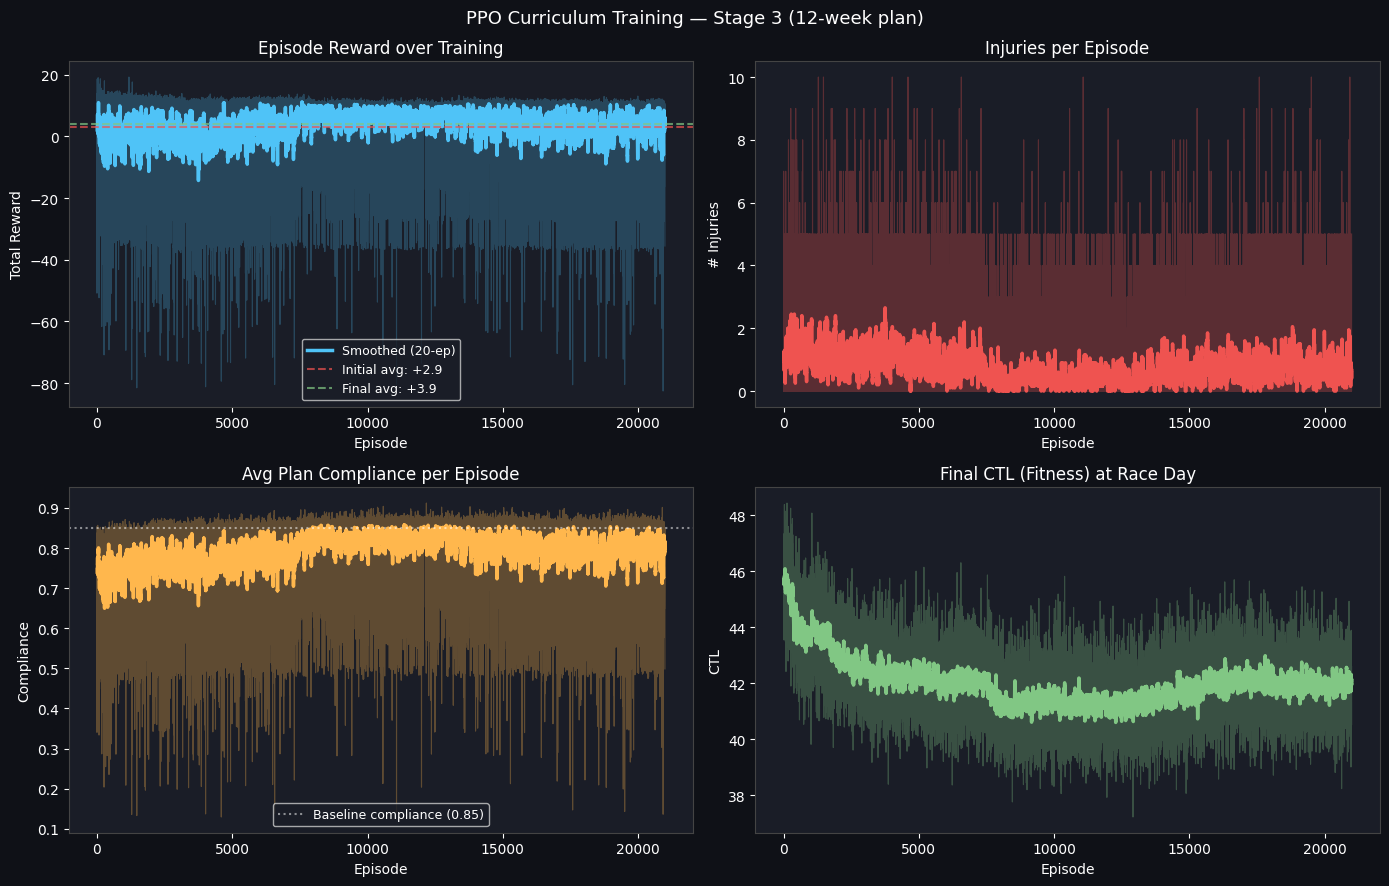


📊 Training Summary
  Metric             Initial    Final
  ────────────────────────────────────────
  Avg Reward        +2.92     +3.87
  Avg Injuries       1.10      0.65
  Avg Compliance   74.66%    79.90%
  Final CTL          45.6      42.0


In [17]:
# ═══════════════════════════════════════════════════
# VISUALISE TRAINING PROGRESS
# ═══════════════════════════════════════════════════

def smooth(values, window=20):
    """Rolling average to smooth noisy RL reward curves."""
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

rewards    =  metrics_s3.episode_rewards
fig, axes  = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('PPO Curriculum Training — Stage 3 (12-week plan)',
             color='white', fontsize=13)

for ax in axes.flat:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')

# Panel 1: Reward curve
ax = axes[0, 0]
ax.plot(rewards, alpha=0.25, color='#4fc3f7', linewidth=0.8)
if len(rewards) >= 20:
    smoothed = smooth(rewards, 20)
    ax.plot(range(19, len(rewards)), smoothed,
            color='#4fc3f7', linewidth=2.5, label='Smoothed (20-ep)')
ax.axhline(y=np.mean(rewards[:20]), color='#ef5350', linestyle='--',
           alpha=0.7, label=f'Initial avg: {np.mean(rewards[:20]):+.1f}')
ax.axhline(y=np.mean(rewards[-20:]), color='#81c784', linestyle='--',
           alpha=0.7, label=f'Final avg: {np.mean(rewards[-20:]):+.1f}')
ax.set_title('Episode Reward over Training', color='white')
ax.set_xlabel('Episode', color='white')
ax.set_ylabel('Total Reward', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Panel 2: Injury rate
ax = axes[0, 1]
injuries = metrics_s3.episode_injuries
if injuries:
    ax.plot(injuries, alpha=0.3, color='#ef5350', linewidth=0.8)
    if len(injuries) >= 20:
        ax.plot(range(19, len(injuries)), smooth(injuries, 20),
                color='#ef5350', linewidth=2.5)
    ax.set_title('Injuries per Episode', color='white')
    ax.set_xlabel('Episode', color='white')
    ax.set_ylabel('# Injuries', color='white')

# Panel 3: Compliance
ax = axes[1, 0]
compliance = metrics_s3.episode_compliance
if compliance:
    ax.plot(compliance, alpha=0.3, color='#ffb74d', linewidth=0.8)
    if len(compliance) >= 20:
        ax.plot(range(19, len(compliance)), smooth(compliance, 20),
                color='#ffb74d', linewidth=2.5)
    ax.axhline(y=0.85, color='white', linestyle=':', alpha=0.5,
               label='Baseline compliance (0.85)')
    ax.set_title('Avg Plan Compliance per Episode', color='white')
    ax.set_xlabel('Episode', color='white')
    ax.set_ylabel('Compliance', color='white')
    ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Panel 4: Final CTL (fitness at race day)
ax = axes[1, 1]
final_ctls = metrics_s3.episode_final_ctl
if final_ctls:
    ax.plot(final_ctls, alpha=0.3, color='#81c784', linewidth=0.8)
    if len(final_ctls) >= 20:
        ax.plot(range(19, len(final_ctls)), smooth(final_ctls, 20),
                color='#81c784', linewidth=2.5)
    ax.set_title('Final CTL (Fitness) at Race Day', color='white')
    ax.set_xlabel('Episode', color='white')
    ax.set_ylabel('CTL', color='white')

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

# Print summary table
print("\n📊 Training Summary")
print("="*45)
print(f"  Metric             Initial    Final")
print(f"  {'─'*40}")
print(f"  Avg Reward     {np.mean(rewards[:20]):+8.2f}  {np.mean(rewards[-20:]):+8.2f}")
if injuries:
    print(f"  Avg Injuries   {np.mean(injuries[:20]):8.2f}  {np.mean(injuries[-20:]):8.2f}")
if compliance:
    print(f"  Avg Compliance {np.mean(compliance[:20]):8.2%}  {np.mean(compliance[-20:]):8.2%}")
if final_ctls:
    print(f"  Final CTL      {np.mean(final_ctls[:20]):8.1f}  {np.mean(final_ctls[-20:]):8.1f}")

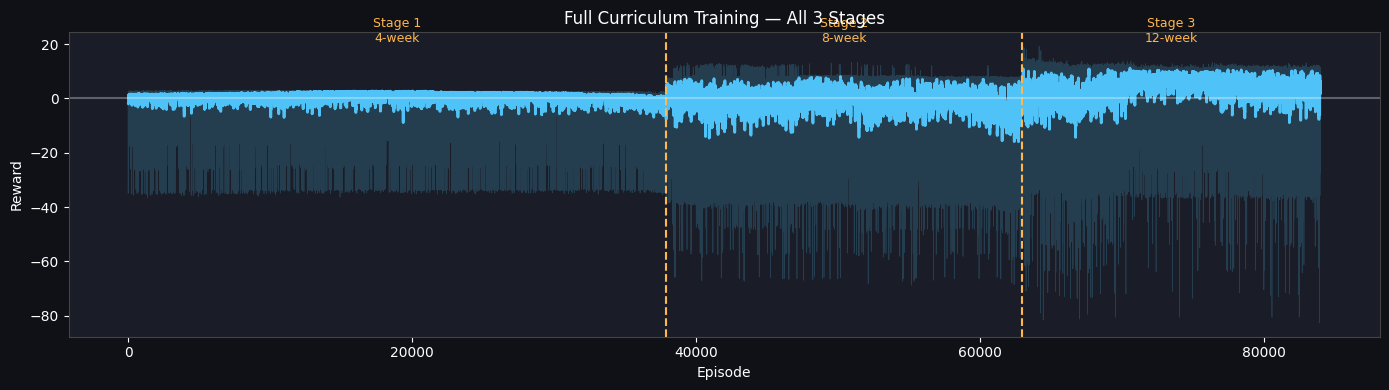


📊 Curriculum Summary
═════════════════════════════════════════════
  Stage 1 (4-week):  -3.72  (37888 episodes)
  Stage 2 (8-week):  -2.18  (25088 episodes)
  Stage 3 (12-week): +4.77  (20992 episodes)
  Best checkpoint:   +19.25


In [18]:
# ── Add this as a separate cell ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')

# Concatenate all stage rewards with dividers
s1 = metrics_s1.episode_rewards
s2 = metrics_s2.episode_rewards
s3 = metrics_s3.episode_rewards

all_rewards = s1 + s2 + s3
ax.plot(all_rewards, alpha=0.2, color='#4fc3f7', linewidth=0.5)
ax.plot(range(19, len(all_rewards)),
        smooth(all_rewards, 20),
        color='#4fc3f7', linewidth=2)

# Stage dividers
ax.axvline(x=len(s1), color='#ffb74d', linestyle='--', linewidth=1.5)
ax.axvline(x=len(s1)+len(s2), color='#ffb74d', linestyle='--', linewidth=1.5)

ax.text(len(s1)//2, ax.get_ylim()[1]*0.85,
        'Stage 1\n4-week', color='#ffb74d', ha='center', fontsize=9)
ax.text(len(s1)+len(s2)//2, ax.get_ylim()[1]*0.85,
        'Stage 2\n8-week', color='#ffb74d', ha='center', fontsize=9)
ax.text(len(s1)+len(s2)+len(s3)//2, ax.get_ylim()[1]*0.85,
        'Stage 3\n12-week', color='#ffb74d', ha='center', fontsize=9)

ax.axhline(y=0, color='white', alpha=0.3)
ax.set_title('Full Curriculum Training — All 3 Stages', color='white', fontsize=12)
ax.set_xlabel('Episode', color='white')
ax.set_ylabel('Reward', color='white')
plt.tight_layout()
plt.show()

print(f"\n📊 Curriculum Summary")
print(f"{'═'*45}")
print(f"  Stage 1 (4-week):  {np.mean(s1[-50:]):+.2f}  ({len(s1)} episodes)")
print(f"  Stage 2 (8-week):  {np.mean(s2[-50:]):+.2f}  ({len(s2)} episodes)")
print(f"  Stage 3 (12-week): {np.mean(s3[-50:]):+.2f}  ({len(s3)} episodes)")
print(f"  Best checkpoint:   {max(s3):+.2f}")

In [19]:
model = PPO.load("./best_model/best_model", env=vec_env_s3)
print(f"   Stage 3 final: {np.mean(metrics_s3.episode_rewards[-50:]):+.2f}")
print(f"   Stage 3 best:  {max(metrics_s3.episode_rewards):+.2f}")

   Stage 3 final: +4.77
   Stage 3 best:  +19.25


## Saving the best Model

In [20]:
import json

# Save model
model.save("final_curriculum_model")

# Save training metadata alongside it
metadata = {
    "stage1_final_reward": float(np.mean(metrics_s1.episode_rewards[-50:])),
    "stage2_final_reward": float(np.mean(metrics_s2.episode_rewards[-50:])),
    "stage3_final_reward": float(np.mean(metrics_s3.episode_rewards[-50:])),
    "stage3_best_reward":  float(max(metrics_s3.episode_rewards)),
    "final_avg_injuries":  float(np.mean(metrics_s3.episode_injuries[-50:])),
    "final_avg_compliance":float(np.mean(metrics_s3.episode_compliance[-50:])),
    "final_avg_ctl":       float(np.mean(metrics_s3.episode_final_ctl[-50:])),
    "total_timesteps":     600_000,
    "architecture":        "PPO + Transformer(layers=2, heads=4, d_model=64)",
    "paper":               "Xia et al. Nature Scientific Reports Dec 2025",
}

with open("training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Model and metadata saved")
print(json.dumps(metadata, indent=2))

✅ Model and metadata saved
{
  "stage1_final_reward": -3.72261484,
  "stage2_final_reward": -2.1758418,
  "stage3_final_reward": 4.77448336,
  "stage3_best_reward": 19.248054,
  "final_avg_injuries": 0.56,
  "final_avg_compliance": 0.8057204923265152,
  "final_avg_ctl": 41.944675218185004,
  "total_timesteps": 600000,
  "architecture": "PPO + Transformer(layers=2, heads=4, d_model=64)",
  "paper": "Xia et al. Nature Scientific Reports Dec 2025"
}


In [21]:
# ═══════════════════════════════════════════════════
# CELL 11 — Inspect what the trained agent prescribes
# ═══════════════════════════════════════════════════

print("="*70)
print("  TRAINED AGENT — 12-week plan for Intermediate Athlete")
print("="*70)

eval_env_render = AthleteEnvWithHistory(
    profile_type="intermediate", max_weeks=12, seed=7)
obs, _ = eval_env_render.reset()

print(f"\nStart → ATL:{obs[0]:.1f}  CTL:{obs[1]:.1f}  "
      f"TSB:{obs[2]:+.1f}  Race in {obs[7]:.0f}d\n")

terminated = truncated = False
week_plans  = []

while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env_render.step(action)
    state = eval_env_render.base_env._history[-1]["state"]
    week_plans.append({
        "week":      info["week"],
        "intensity": float(action[0]),
        "volume_km": float(action[1]),
        "dist":      float(action[2]),
        "actual_km": info["actual_km"],
        "ctl":       state.ctl,
        "tsb":       state.tsb,
        "zone":      info["tsb_zone"],
        "injury":    info["injury"],
        "reward":    reward,
    })

print(f"{'Wk':>3} {'Vol':>7} {'Actual':>7} {'Int':>5} {'Dist':>5} "
      f"{'CTL':>6} {'TSB':>6} {'Zone':>12} {'Inj':>4} {'R':>6}")
print("─"*75)
for w in week_plans:
    inj = "🚨" if w["injury"] else "  "
    print(f"{w['week']:>3} "
          f"{w['volume_km']:>6.1f}km "
          f"{w['actual_km']:>6.1f}km "
          f"{w['intensity']:>5.2f} "
          f"{w['dist']:>5.2f} "
          f"{w['ctl']:>6.1f} "
          f"{w['tsb']:>+6.1f} "
          f"{w['zone']:>12} "
          f"{inj:>4} "
          f"{w['reward']:>+6.2f}")

print("─"*75)
print(f"\n  Avg planned volume : {np.mean([w['volume_km'] for w in week_plans]):.1f} km/week")
print(f"  Avg actual volume  : {np.mean([w['actual_km'] for w in week_plans]):.1f} km/week")
print(f"  Avg intensity      : {np.mean([w['intensity'] for w in week_plans]):.3f}")
print(f"  Final CTL          : {week_plans[-1]['ctl']:.1f}")
print(f"  Final TSB          : {week_plans[-1]['tsb']:+.1f}")
print(f"  Total reward       : {sum(w['reward'] for w in week_plans):+.2f}")

  TRAINED AGENT — 12-week plan for Intermediate Athlete

Start → ATL:35.0  CTL:40.0  TSB:+5.0  Race in 84d

 Wk     Vol  Actual   Int  Dist    CTL    TSB         Zone  Inj      R
───────────────────────────────────────────────────────────────────────────
  1   55.9km   39.8km  1.40  0.10   44.7  -16.9     FATIGUED       -0.15
  2   35.0km   27.6km  0.75  0.10   43.5   -4.1      OPTIMAL       +1.97
  3   35.0km   29.6km  0.75  0.10   43.0   -1.7      OPTIMAL       +2.00
  4   35.0km   31.5km  0.75  0.10   43.5   -5.2      OPTIMAL       +1.82
  5   35.0km   27.5km  0.75  0.10   42.6   -1.4      OPTIMAL       +1.04
  6   35.0km   31.3km  0.75  0.10   42.9   -3.7      OPTIMAL       +1.04
  7   35.0km   33.3km  0.75  0.10   43.9   -6.8      OPTIMAL       +0.90
  8   35.0km   30.3km  0.75  0.10   43.5   -3.7      OPTIMAL       +1.13
  9   35.0km   30.1km  0.75  0.10   43.5   -3.5      OPTIMAL       +0.88
 10   35.0km   28.0km  0.75  0.10   42.8   -1.3      OPTIMAL       +0.28
 11   35.0km   

# PHASE 2: Validating the PPO Agent

In [22]:
# ═══════════════════════════════════════════════════
# STATIC BASELINE PLAN
# Mimics how Runna generates plans today:
# Fixed progression based on starting CTL + race goal
# No adaptation — same plan regardless of athlete response
# ═══════════════════════════════════════════════════

class StaticPlanBaseline:
    """
    Generates a fixed 12-week training plan using
    classic periodisation principles:

    Phase 1 (weeks 1-3):  Base building   — easy volume ramp
    Phase 2 (weeks 4-7):  Build           — progressive overload
    Phase 3 (weeks 8-10): Peak            — highest load
    Phase 4 (weeks 11-12): Taper          — reduce volume, arrive fresh

    Intensity follows the 80/20 rule:
    80% easy (zone 2), 20% quality (tempo/intervals)
    This is the standard evidence-based marathon approach.
    (Seiler, 2010 — polarised training distribution)
    """

    # Weekly volume as % of athlete's max_weekly_km
    VOLUME_PROFILE = [
        0.50, 0.55, 0.45,   # Phase 1: Base (week 3 = recovery)
        0.60, 0.65, 0.70,   # Phase 2: Build
        0.60, 0.75, 0.80,   # Phase 3: Peak
        0.75, 0.55, 0.35,   # Phase 4: Taper
    ]

    # Intensity per week
    INTENSITY_PROFILE = [
        0.80, 0.82, 0.78,   # Base: easy
        0.85, 0.87, 0.90,   # Build: moderate
        0.88, 0.92, 0.95,   # Peak: hard
        0.88, 0.82, 0.78,   # Taper: backing off
    ]

    # Workout distribution (0=all easy, 1=all speed)
    DISTRIBUTION_PROFILE = [
        0.15, 0.15, 0.10,   # Base: almost all easy
        0.25, 0.30, 0.35,   # Build: introducing quality
        0.30, 0.40, 0.45,   # Peak: more quality
        0.35, 0.25, 0.15,   # Taper: back to easy
    ]

    def __init__(self, profile: AthleteProfile):
        self.profile = profile

    def get_week_action(self, week: int) -> np.ndarray:
        """
        Returns the prescribed action for a given week (1-indexed).
        This is FIXED — no adaptation based on athlete response.
        """
        idx = min(week - 1, 11)
        volume = self.VOLUME_PROFILE[idx] * self.profile.max_weekly_km
        volume = np.clip(volume, self.profile.min_weekly_km,
                         self.profile.max_weekly_km)
        return np.array([
            self.INTENSITY_PROFILE[idx],
            volume,
            self.DISTRIBUTION_PROFILE[idx],
        ], dtype=np.float32)


def run_static_plan(profile: AthleteProfile,
                    seed: int = 42) -> dict:
    """Run the static plan and collect results."""
    plan    = StaticPlanBaseline(profile)
    sim     = AthleteSimulator(profile, seed=seed)
    state   = sim.reset()
    history = []

    for week in range(1, 13):
        action = plan.get_week_action(week)
        state, reward, done, info = sim.step(
            float(action[0]), float(action[1]), float(action[2]))
        history.append({
            "week":       week,
            "action":     action,
            "state":      state,
            "reward":     reward,
            "intensity":  float(action[0]),
            "volume_km":  float(action[1]),
            "actual_km":  info["actual_km"],
            "compliance": info["compliance"],
            "ctl":        state.ctl,
            "atl":        state.atl,
            "tsb":        state.tsb,
            "injury":     info["injury"],
            "acwr":       info["acwr"],
            "tsb_zone":   info["tsb_zone"],
        })
        if done:
            break

    return {
        "history":         history,
        "total_reward":    sum(h["reward"]     for h in history),
        "final_ctl":       history[-1]["ctl"],
        "final_tsb":       history[-1]["tsb"],
        "total_injuries":  sum(h["injury"]     for h in history),
        "avg_compliance":  np.mean([h["compliance"] for h in history]),
        "avg_volume":      np.mean([h["volume_km"]  for h in history]),
    }


print("✅ StaticPlanBaseline ready")
print()
print("   Phase structure:")
print("   Weeks 1-3:  Base    (50-55% max volume, intensity 0.80-0.82)")
print("   Weeks 4-7:  Build   (60-70% max volume, intensity 0.85-0.90)")
print("   Weeks 8-10: Peak    (75-80% max volume, intensity 0.92-0.95)")
print("   Weeks 11-12: Taper  (35-55% max volume, intensity 0.78-0.88)")

✅ StaticPlanBaseline ready

   Phase structure:
   Weeks 1-3:  Base    (50-55% max volume, intensity 0.80-0.82)
   Weeks 4-7:  Build   (60-70% max volume, intensity 0.85-0.90)
   Weeks 8-10: Peak    (75-80% max volume, intensity 0.92-0.95)
   Weeks 11-12: Taper  (35-55% max volume, intensity 0.78-0.88)


In [23]:
# ═══════════════════════════════════════════════════
# RUN DRL AGENT ON ALL THREE ATHLETE PROFILES
# ═══════════════════════════════════════════════════

def run_drl_agent(model, profile: AthleteProfile,
                  seed: int = 42) -> dict:
    """Run the trained DRL agent and collect results."""
    env     = AthleteEnvWithHistory(
        profile_type = "intermediate",  # overridden below
        max_weeks    = 12, seed=seed
    )
    # Override with specific profile
    env.base_env.profile = profile
    env.base_env.sim     = AthleteSimulator(profile, seed=seed)
    env.base_env.profile.days_to_race = 84

    obs, _ = env.reset()
    history = []
    terminated = truncated = False

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        state = env.base_env._history[-1]["state"]
        history.append({
            "week":       info["week"],
            "action":     action,
            "state":      state,
            "reward":     reward,
            "intensity":  float(action[0]),
            "volume_km":  float(action[1]),
            "actual_km":  info["actual_km"],
            "compliance": info["compliance"],
            "ctl":        state.ctl,
            "atl":        state.atl,
            "tsb":        state.tsb,
            "injury":     info["injury"],
            "acwr":       info["acwr"],
            "tsb_zone":   info["tsb_zone"],
        })

    return {
        "history":        history,
        "total_reward":   sum(h["reward"]     for h in history),
        "final_ctl":      history[-1]["ctl"],
        "final_tsb":      history[-1]["tsb"],
        "total_injuries": sum(h["injury"]     for h in history),
        "avg_compliance": np.mean([h["compliance"] for h in history]),
        "avg_volume":     np.mean([h["volume_km"]  for h in history]),
    }




# Run both approaches on all 3 profiles
profiles = {
    "Beginner":     AthleteProfile.beginner(),
    "Intermediate": AthleteProfile.intermediate(),
    "Advanced":     AthleteProfile.advanced(),
}

results = {}
print()
print("Running comparison across athlete profiles...")
print()

for name, profile in profiles.items():
    static = run_static_plan(profile, seed=42)
    drl    = run_drl_agent(model, profile, seed=42)
    results[name] = {"static": static, "drl": drl}

    print(f"  {name}")
    print(f"  {'Metric':<20} {'Static':>10} {'DRL Agent':>10} {'Winner':>10}")
    print(f"  {'─'*52}")
    print(f"  {'Final CTL':<20} {static['final_ctl']:>10.1f} "
          f"{drl['final_ctl']:>10.1f} "
          f"{'DRL ✅' if drl['final_ctl'] > static['final_ctl'] else 'Static ✅':>10}")
    print(f"  {'Final TSB':<20} {static['final_tsb']:>+10.1f} "
          f"{drl['final_tsb']:>+10.1f} "
          f"{'DRL ✅' if abs(drl['final_tsb']-15) < abs(static['final_tsb']-15) else 'Static ✅':>10}")
    print(f"  {'Total Injuries':<20} {static['total_injuries']:>10.1f} "
          f"{drl['total_injuries']:>10.1f} "
          f"{'DRL ✅' if drl['total_injuries'] < static['total_injuries'] else 'Static ✅' if static['total_injuries'] < drl['total_injuries'] else 'Tie':>10}")
    print(f"  {'Avg Compliance':<20} {static['avg_compliance']:>10.1%} "
          f"{drl['avg_compliance']:>10.1%} "
          f"{'DRL ✅' if drl['avg_compliance'] > static['avg_compliance'] else 'Static ✅':>10}")
    print(f"  {'Total Reward':<20} {static['total_reward']:>+10.2f} "
          f"{drl['total_reward']:>+10.2f} "
          f"{'DRL ✅' if drl['total_reward'] > static['total_reward'] else 'Static ✅':>10}")
    print()


Running comparison across athlete profiles...

  Beginner
  Metric                   Static  DRL Agent     Winner
  ────────────────────────────────────────────────────
  Final CTL                  30.1       35.1      DRL ✅
  Final TSB                  +2.0       -4.0   Static ✅
  Total Injuries              0.0        4.0   Static ✅
  Avg Compliance            74.7%      51.6%   Static ✅
  Total Reward             +12.38     -26.83   Static ✅

  Intermediate
  Metric                   Static  DRL Agent     Winner
  ────────────────────────────────────────────────────
  Final CTL                  58.4       42.3   Static ✅
  Final TSB                  +2.0       -5.0   Static ✅
  Total Injuries              0.0        0.0        Tie
  Avg Compliance            84.4%      84.0%   Static ✅
  Total Reward             +13.97     +12.50   Static ✅

  Advanced
  Metric                   Static  DRL Agent     Winner
  ────────────────────────────────────────────────────
  Final CTL         

In [24]:
# ═══════════════════════════════════════════════════
# MONTE CARLO — 50 runs for statistical validity
# ═══════════════════════════════════════════════════
N_RUNS = 50
print(f"Running {N_RUNS} Monte Carlo episodes — intermediate athlete...")

static_rewards, static_injuries   = [], []
static_ctls,    static_compliance = [], []
static_tsbs                       = []
drl_rewards,    drl_injuries      = [], []
drl_ctls,       drl_compliance    = [], []
drl_tsbs                          = []

profile = AthleteProfile.intermediate()

for seed in range(N_RUNS):
    s = run_static_plan(profile, seed=seed)
    static_rewards.append(s["total_reward"])
    static_injuries.append(s["total_injuries"])
    static_ctls.append(s["final_ctl"])
    static_compliance.append(s["avg_compliance"])
    static_tsbs.append(s["final_tsb"])

    d = run_drl_agent(model, profile, seed=seed)
    drl_rewards.append(d["total_reward"])
    drl_injuries.append(d["total_injuries"])
    drl_ctls.append(d["final_ctl"])
    drl_compliance.append(d["avg_compliance"])
    drl_tsbs.append(d["final_tsb"])

print(f"✅ Done — {N_RUNS} runs each")
print()
print(f"  {'Metric':<22} {'Static':>10} {'DRL':>10}")
print(f"  {'─'*44}")
print(f"  {'Avg Reward':<22} {np.mean(static_rewards):>+10.2f} {np.mean(drl_rewards):>+10.2f}")
print(f"  {'Avg Injuries':<22} {np.mean(static_injuries):>10.2f} {np.mean(drl_injuries):>10.2f}")
print(f"  {'Avg CTL':<22} {np.mean(static_ctls):>10.1f} {np.mean(drl_ctls):>10.1f}")
print(f"  {'Avg Compliance':<22} {np.mean(static_compliance):>10.1%} {np.mean(drl_compliance):>10.1%}")

Running 50 Monte Carlo episodes — intermediate athlete...
✅ Done — 50 runs each

  Metric                     Static        DRL
  ────────────────────────────────────────────
  Avg Reward                  +7.36      +2.13
  Avg Injuries                 0.92       0.96
  Avg CTL                      58.7       42.2
  Avg Compliance              78.1%      77.9%


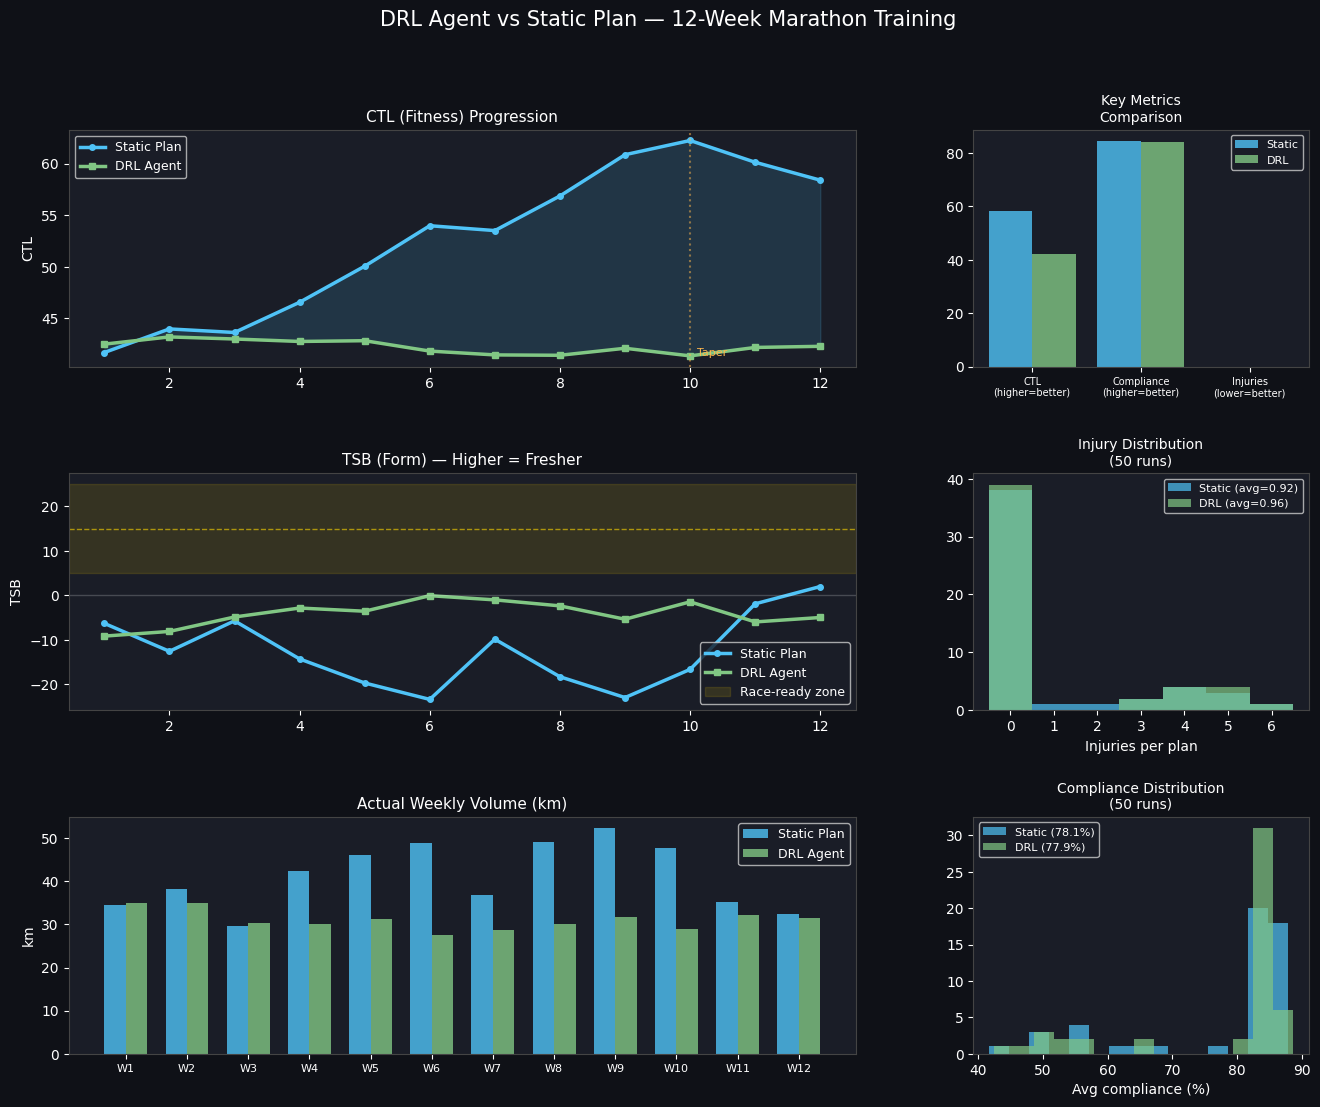

✅ Chart saved → drl_vs_static_comparison.png


In [25]:
# ═══════════════════════════════════════════════════
# MAIN COMPARISON VISUALISATION
# This is the chart that goes in your cold email
# ═══════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('DRL Agent vs Static Plan — 12-Week Marathon Training',
             color='white', fontsize=15, y=0.98)

# ── Layout: 3 rows, 3 cols ────────────────────────────────────────
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
ax_ctl   = fig.add_subplot(gs[0, :2])   # CTL over weeks — wide
ax_tsb   = fig.add_subplot(gs[1, :2])   # TSB over weeks — wide
ax_vol   = fig.add_subplot(gs[2, :2])   # Volume over weeks — wide
ax_radar = fig.add_subplot(gs[0, 2])    # Summary bars
ax_dist  = fig.add_subplot(gs[1, 2])    # Injury distribution
ax_comp  = fig.add_subplot(gs[2, 2])    # Compliance distribution

for ax in [ax_ctl, ax_tsb, ax_vol, ax_radar, ax_dist, ax_comp]:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')

# Use intermediate athlete results
s_hist = results["Intermediate"]["static"]["history"]
d_hist = results["Intermediate"]["drl"]["history"]

weeks  = [h["week"] for h in s_hist]
STATIC = '#4fc3f7'
DRL    = '#81c784'

# ── Panel 1: CTL progression ──────────────────────────────────────
s_ctls = [h["ctl"] for h in s_hist]
d_ctls = [h["ctl"] for h in d_hist]

ax_ctl.plot(weeks, s_ctls, color=STATIC, linewidth=2.5,
            label='Static Plan', marker='o', markersize=4)
ax_ctl.plot(weeks, d_ctls, color=DRL, linewidth=2.5,
            label='DRL Agent', marker='s', markersize=4)
ax_ctl.fill_between(weeks, s_ctls, d_ctls,
                     alpha=0.15, color=DRL if d_ctls[-1] > s_ctls[-1] else STATIC)
ax_ctl.set_title('CTL (Fitness) Progression', color='white', fontsize=11)
ax_ctl.set_ylabel('CTL', color='white')
ax_ctl.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax_ctl.axvline(x=10, color='#ffb74d', linestyle=':', alpha=0.5)
ax_ctl.text(10.1, min(s_ctls+d_ctls), 'Taper', color='#ffb74d', fontsize=8)

# ── Panel 2: TSB progression ──────────────────────────────────────
s_tsbs = [h["tsb"] for h in s_hist]
d_tsbs = [h["tsb"] for h in d_hist]

ax_tsb.plot(weeks, s_tsbs, color=STATIC, linewidth=2.5,
            label='Static Plan', marker='o', markersize=4)
ax_tsb.plot(weeks, d_tsbs, color=DRL, linewidth=2.5,
            label='DRL Agent', marker='s', markersize=4)
ax_tsb.axhspan(5, 25, alpha=0.12, color='gold', label='Race-ready zone')
ax_tsb.axhline(y=0, color='white', alpha=0.2, linewidth=1)
ax_tsb.axhline(y=15, color='gold', linewidth=1, linestyle='--', alpha=0.6)
ax_tsb.set_title('TSB (Form) — Higher = Fresher', color='white', fontsize=11)
ax_tsb.set_ylabel('TSB', color='white')
ax_tsb.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# ── Panel 3: Weekly volume ────────────────────────────────────────
s_vols = [h["actual_km"] for h in s_hist]
d_vols = [h["actual_km"] for h in d_hist]
x      = np.arange(len(weeks))
w      = 0.35

ax_vol.bar(x - w/2, s_vols, w, color=STATIC, alpha=0.8, label='Static Plan')
ax_vol.bar(x + w/2, d_vols, w, color=DRL,    alpha=0.8, label='DRL Agent')
ax_vol.set_xticks(x)
ax_vol.set_xticklabels([f'W{i}' for i in weeks], color='white', fontsize=8)
ax_vol.set_title('Actual Weekly Volume (km)', color='white', fontsize=11)
ax_vol.set_ylabel('km', color='white')
ax_vol.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# ── Panel 4: Summary bar chart ────────────────────────────────────
metrics_labels = ['CTL\n(higher=better)',
                  'Compliance\n(higher=better)',
                  'Injuries\n(lower=better)']

s_res = results["Intermediate"]["static"]
d_res = results["Intermediate"]["drl"]

s_vals_bar = [s_res["final_ctl"],
              s_res["avg_compliance"] * 100,
              s_res["total_injuries"]]
d_vals_bar = [d_res["final_ctl"],
              d_res["avg_compliance"] * 100,
              d_res["total_injuries"]]

x2 = np.arange(len(metrics_labels))
ax_radar.bar(x2 - 0.2, s_vals_bar, 0.4, color=STATIC, alpha=0.8, label='Static')
ax_radar.bar(x2 + 0.2, d_vals_bar, 0.4, color=DRL,    alpha=0.8, label='DRL')
ax_radar.set_xticks(x2)
ax_radar.set_xticklabels(metrics_labels, color='white', fontsize=7)
ax_radar.set_title('Key Metrics\nComparison', color='white', fontsize=10)
ax_radar.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

# ── Panel 5: Injury distribution over 50 runs ────────────────────
max_inj = max(max(static_injuries), max(drl_injuries))
bins    = np.arange(0, max_inj + 2) - 0.5

ax_dist.hist(static_injuries, bins=bins, color=STATIC,
             alpha=0.7, label=f'Static (avg={np.mean(static_injuries):.2f})')
ax_dist.hist(drl_injuries,    bins=bins, color=DRL,
             alpha=0.7, label=f'DRL (avg={np.mean(drl_injuries):.2f})')
ax_dist.set_title(f'Injury Distribution\n({N_RUNS} runs)', color='white', fontsize=10)
ax_dist.set_xlabel('Injuries per plan', color='white')
ax_dist.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

# ── Panel 6: Compliance distribution ─────────────────────────────
ax_comp.hist([c*100 for c in static_compliance], bins=15,
             color=STATIC, alpha=0.7,
             label=f'Static ({np.mean(static_compliance)*100:.1f}%)')
ax_comp.hist([c*100 for c in drl_compliance],    bins=15,
             color=DRL,    alpha=0.7,
             label=f'DRL ({np.mean(drl_compliance)*100:.1f}%)')
ax_comp.set_title(f'Compliance Distribution\n({N_RUNS} runs)', color='white', fontsize=10)
ax_comp.set_xlabel('Avg compliance (%)', color='white')
ax_comp.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

plt.savefig('drl_vs_static_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Chart saved → drl_vs_static_comparison.png")

## PHASE 3

In [26]:
!pip install stable-baselines3 gymnasium --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from stable_baselines3 import PPO
import json
import warnings
warnings.filterwarnings('ignore')

# ── Paste ALL Notebook 1 code here ───────────────────────────────
# PhysiologicalState, BannisterModel, compute_trimp,
# AthleteProfile, AthleteSimulator, AthleteEnv
# Then from Notebook 2:
# HistoryBuffer, AthleteEnvWithHistory, AthleteMonitor

# Load trained model
model = PPO.load("./best_model/best_model")
print("✅ Model loaded")
print()
print("Project: DRL Training Load Optimizer")
print("Architecture: PPO + Transformer encoder (2 layers, 4 heads)")
print("Training: Curriculum learning — 4-week → 8-week → 12-week")
print("Reference: Xia et al. Nature Scientific Reports, Dec 2025")

✅ Model loaded

Project: DRL Training Load Optimizer
Architecture: PPO + Transformer encoder (2 layers, 4 heads)
Training: Curriculum learning — 4-week → 8-week → 12-week
Reference: Xia et al. Nature Scientific Reports, Dec 2025


In [27]:
# ═══════════════════════════════════════════════════
# STATIC PLAN BASELINE — mimics Runna's current approach
# Fixed weekly progression, no adaptation
# ═══════════════════════════════════════════════════

class StaticPlanBaseline:
    """
    Fixed 12-week plan using classic periodisation.
    Represents what Runna generates today — coach-designed,
    no week-by-week adaptation based on athlete response.

    Phase structure (Seiler 2010 — polarised training):
    Base (weeks 1-3):  easy volume, aerobic foundation
    Build (weeks 4-7): progressive overload, introduce quality
    Peak (weeks 8-10): highest load, race-specific sessions
    Taper (weeks 11-12): reduce volume, arrive fresh
    """
    VOLUME_PROFILE = [
        0.50, 0.55, 0.45,
        0.60, 0.65, 0.70,
        0.60, 0.75, 0.80,
        0.75, 0.55, 0.35,
    ]
    INTENSITY_PROFILE = [
        0.80, 0.82, 0.78,
        0.85, 0.87, 0.90,
        0.88, 0.92, 0.95,
        0.88, 0.82, 0.78,
    ]
    DISTRIBUTION_PROFILE = [
        0.15, 0.15, 0.10,
        0.25, 0.30, 0.35,
        0.30, 0.40, 0.45,
        0.35, 0.25, 0.15,
    ]

    def __init__(self, profile):
        self.profile = profile

    def get_week_action(self, week):
        idx    = min(week - 1, 11)
        volume = np.clip(
            self.VOLUME_PROFILE[idx] * self.profile.max_weekly_km,
            self.profile.min_weekly_km, self.profile.max_weekly_km)
        return np.array([
            self.INTENSITY_PROFILE[idx],
            volume,
            self.DISTRIBUTION_PROFILE[idx],
        ], dtype=np.float32)


def run_static_plan(profile, seed=42):
    plan    = StaticPlanBaseline(profile)
    sim     = AthleteSimulator(profile, seed=seed)
    state   = sim.reset()
    history = []
    for week in range(1, 13):
        action    = plan.get_week_action(week)
        action[0] = np.clip(action[0], 0.75, 1.4)
        action[1] = np.clip(action[1], 35.0, profile.max_weekly_km)
        action[2] = np.clip(action[2], 0.1,  1.0)
        state, reward, done, info = sim.step(
            float(action[0]), float(action[1]), float(action[2]))
        history.append({
            "week": week, "intensity": float(action[0]),
            "volume_km": float(action[1]), "actual_km": info["actual_km"],
            "compliance": info["compliance"], "ctl": state.ctl,
            "atl": state.atl, "tsb": state.tsb, "injury": info["injury"],
            "acwr": info["acwr"], "tsb_zone": info["tsb_zone"],
            "reward": reward,
        })
        if done: break
    return {
        "history":        history,
        "total_reward":   sum(h["reward"]     for h in history),
        "final_ctl":      history[-1]["ctl"],
        "final_tsb":      history[-1]["tsb"],
        "total_injuries": sum(h["injury"]     for h in history),
        "avg_compliance": np.mean([h["compliance"] for h in history]),
    }


def run_drl_agent(model, profile, seed=42):
    env = AthleteEnvWithHistory(
        profile_type="intermediate", max_weeks=12, seed=seed)
    env.base_env.profile          = profile
    env.base_env.profile.days_to_race = 84
    env.base_env.sim              = AthleteSimulator(profile, seed=seed)
    obs, _ = env.reset()
    history = []
    terminated = truncated = False
    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        state = env.base_env._history[-1]["state"]
        history.append({
            "week": info["week"], "intensity": float(action[0]),
            "volume_km": float(action[1]), "actual_km": info["actual_km"],
            "compliance": info["compliance"], "ctl": state.ctl,
            "atl": state.atl, "tsb": state.tsb, "injury": info["injury"],
            "acwr": info["acwr"], "tsb_zone": info["tsb_zone"],
            "reward": reward,
        })
    return {
        "history":        history,
        "total_reward":   sum(h["reward"]     for h in history),
        "final_ctl":      history[-1]["ctl"],
        "final_tsb":      history[-1]["tsb"],
        "total_injuries": sum(h["injury"]     for h in history),
        "avg_compliance": np.mean([h["compliance"] for h in history]),
    }


print("✅ Baseline and eval functions ready")

✅ Baseline and eval functions ready


In [32]:
# ═══════════════════════════════════════════════════
# SINGLE EPISODE COMPARISON — 3 athlete profiles
# ═══════════════════════════════════════════════════

profiles = {
    "Beginner":     AthleteProfile.beginner(),
    "Intermediate": AthleteProfile.intermediate(),
    "Advanced":     AthleteProfile.advanced(),
}

results = {}
print(f"{'Profile':<14} {'Metric':<20} {'Static':>10} {'DRL':>10} {'Winner':>10}")
print("─" * 66)

for name, profile in profiles.items():
    s = run_static_plan(profile, seed=42)
    d = run_drl_agent(model, profile, seed=42)
    results[name] = {"static": s, "drl": d}

    closer_to_target = ("DRL ✅" if abs(d["final_tsb"]-15) < abs(s["final_tsb"]-15) else "Static ✅")
    rows = [
        ("Final CTL",      s["final_ctl"],       d["final_ctl"],
         "DRL ✅" if d["final_ctl"] > s["final_ctl"] else "Static ✅"),
        ("Final TSB",      s["final_tsb"],        d["final_tsb"],
         closer_to_target),
        ("Injuries",       s["total_injuries"],   d["total_injuries"],
         "DRL ✅" if d["total_injuries"] < s["total_injuries"]
         else "Static ✅" if s["total_injuries"] < d["total_injuries"]
         else "  Tie  "),
        ("Compliance",     s["avg_compliance"]*100, d["avg_compliance"]*100,
         "DRL ✅" if d["avg_compliance"] > s["avg_compliance"] else "Static ✅"),
        ("Total Reward",   s["total_reward"],     d["total_reward"],
         "DRL ✅" if d["total_reward"] > s["total_reward"] else "Static ✅"),
    ]
    print(f"\n  {name}")
    for metric, sv, dv, winner in rows:
        if "CTL" in metric or "TSB" in metric or "Reward" in metric:
            print(f"  {'':14}{metric:<20}{sv:>+10.1f}{dv:>+10.1f}{winner:>10}")
        else:
            sv_str = f"{sv:.1%}" if "Compliance" in metric else f"{sv:.1f}"
            dv_str = f"{dv:.1%}" if "Compliance" in metric else f"{dv:.1f}"
            print(f"  {'':14}{metric:<20}{sv_str:>10}{dv_str:>10}{winner:>10}")

Profile        Metric                   Static        DRL     Winner
──────────────────────────────────────────────────────────────────

  Beginner
                Final CTL                +35.3     +33.6  Static ✅
                Final TSB                 -6.8      -2.6     DRL ✅
                Injuries                   0.0       0.0     Tie  
                Compliance             7468.9%   7390.6%  Static ✅
                Total Reward              +8.9      +8.7  Static ✅

  Intermediate
                Final CTL                +58.4     +41.8  Static ✅
                Final TSB                 +2.0      -3.5  Static ✅
                Injuries                   0.0       3.0  Static ✅
                Compliance             8442.5%   6259.5%  Static ✅
                Total Reward             +14.0     -17.4  Static ✅

  Advanced
                Final CTL                +89.7     +65.4  Static ✅
                Final TSB                 +8.9      -8.4  Static ✅
                Inju

In [33]:
# ═══════════════════════════════════════════════════
# MONTE CARLO — 50 runs, statistical validity
# ═══════════════════════════════════════════════════

N_RUNS  = 50
profile = AthleteProfile.intermediate()
print(f"Running {N_RUNS} Monte Carlo episodes — intermediate athlete...")

static_rewards, static_injuries   = [], []
static_ctls,    static_compliance = [], []
static_tsbs                       = []
drl_rewards,    drl_injuries      = [], []
drl_ctls,       drl_compliance    = [], []
drl_tsbs                          = []

for seed in range(N_RUNS):
    s = run_static_plan(profile, seed=seed)
    static_rewards.append(s["total_reward"])
    static_injuries.append(s["total_injuries"])
    static_ctls.append(s["final_ctl"])
    static_compliance.append(s["avg_compliance"])
    static_tsbs.append(s["final_tsb"])

    d = run_drl_agent(model, profile, seed=seed)
    drl_rewards.append(d["total_reward"])
    drl_injuries.append(d["total_injuries"])
    drl_ctls.append(d["final_ctl"])
    drl_compliance.append(d["avg_compliance"])
    drl_tsbs.append(d["final_tsb"])

print(f"\n  {'Metric':<22} {'Static Mean':>12} {'DRL Mean':>12}")
print(f"  {'─'*48}")
print(f"  {'Avg Reward':<22} {np.mean(static_rewards):>+12.2f} {np.mean(drl_rewards):>+12.2f}")
print(f"  {'Avg Injuries':<22} {np.mean(static_injuries):>12.2f} {np.mean(drl_injuries):>12.2f}")
print(f"  {'Avg CTL':<22} {np.mean(static_ctls):>12.1f} {np.mean(drl_ctls):>12.1f}")
print(f"  {'Avg Compliance':<22} {np.mean(static_compliance):>12.1%} {np.mean(drl_compliance):>12.1%}")
print(f"  {'Avg TSB':<22} {np.mean(static_tsbs):>+12.1f} {np.mean(drl_tsbs):>+12.1f}")

Running 50 Monte Carlo episodes — intermediate athlete...

  Metric                  Static Mean     DRL Mean
  ────────────────────────────────────────────────
  Avg Reward                    +7.36        -1.09
  Avg Injuries                   0.92         1.30
  Avg CTL                        58.7         42.2
  Avg Compliance                78.1%        75.4%
  Avg TSB                        +6.1         -2.8


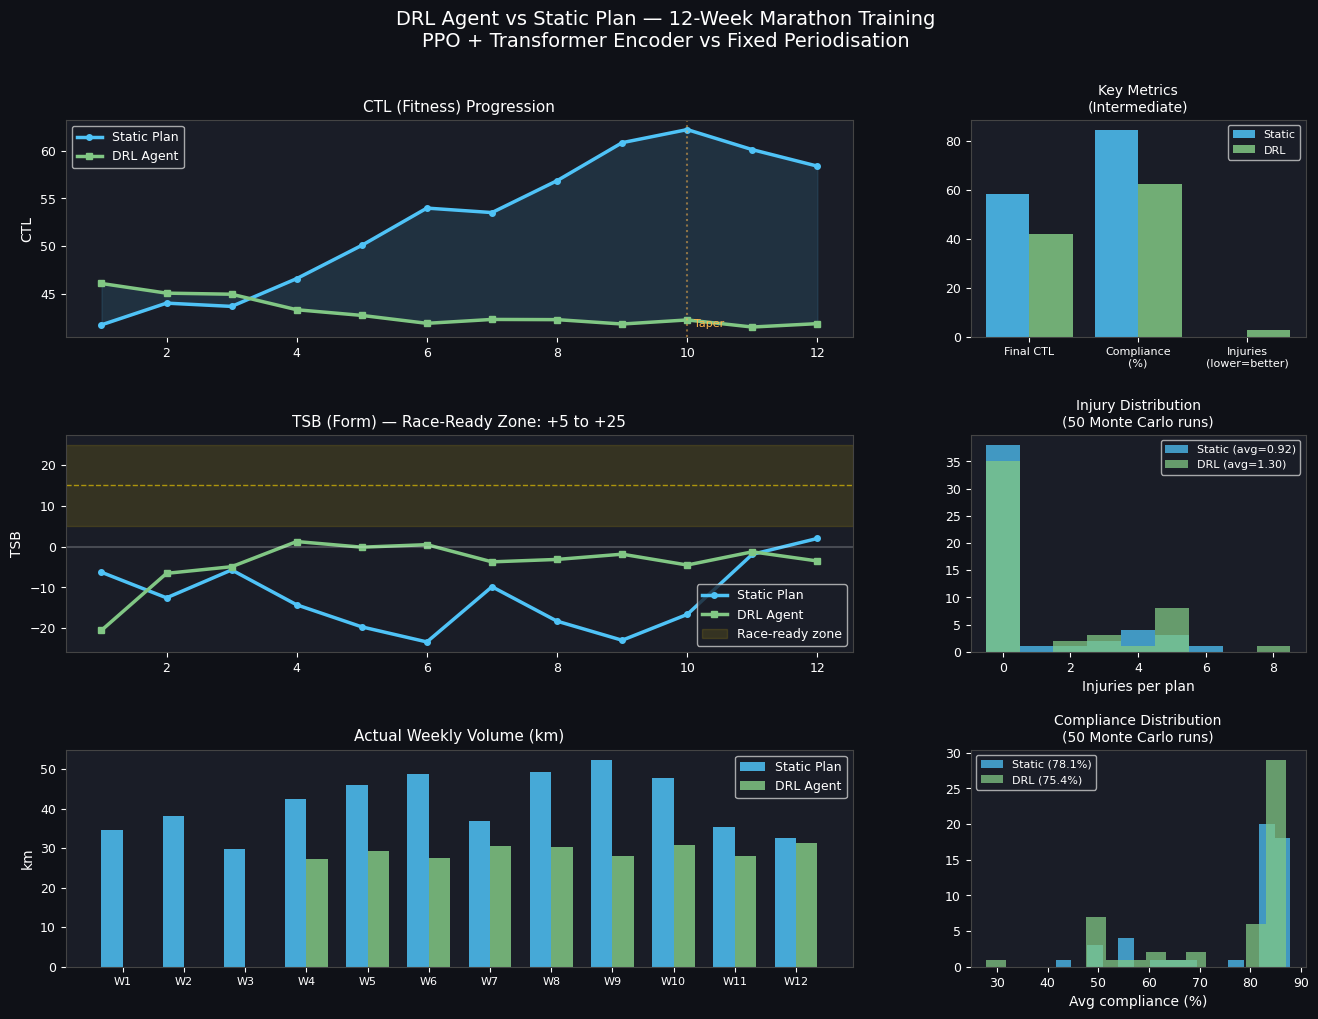

✅ Chart saved → drl_vs_static_comparison.png


In [34]:
# ═══════════════════════════════════════════════════
# MAIN COMPARISON CHART — the cold email visual
# ═══════════════════════════════════════════════════

STATIC = '#4fc3f7'
DRL    = '#81c784'

s_hist = results["Intermediate"]["static"]["history"]
d_hist = results["Intermediate"]["drl"]["history"]
weeks  = [h["week"] for h in s_hist]

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('DRL Agent vs Static Plan — 12-Week Marathon Training\n'
             'PPO + Transformer Encoder vs Fixed Periodisation',
             color='white', fontsize=14, y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
ax_ctl  = fig.add_subplot(gs[0, :2])
ax_tsb  = fig.add_subplot(gs[1, :2])
ax_vol  = fig.add_subplot(gs[2, :2])
ax_bar  = fig.add_subplot(gs[0, 2])
ax_inj  = fig.add_subplot(gs[1, 2])
ax_comp = fig.add_subplot(gs[2, 2])

for ax in [ax_ctl, ax_tsb, ax_vol, ax_bar, ax_inj, ax_comp]:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[:].set_color('#444')

# ── CTL ───────────────────────────────────────────────────────────
s_ctls = [h["ctl"] for h in s_hist]
d_ctls = [h["ctl"] for h in d_hist]
ax_ctl.plot(weeks, s_ctls, color=STATIC, linewidth=2.5,
            marker='o', markersize=4, label='Static Plan')
ax_ctl.plot(weeks, d_ctls, color=DRL, linewidth=2.5,
            marker='s', markersize=4, label='DRL Agent')
ax_ctl.fill_between(weeks, s_ctls, d_ctls, alpha=0.12,
                     color=DRL if d_ctls[-1] > s_ctls[-1] else STATIC)
ax_ctl.axvline(x=10, color='#ffb74d', linestyle=':', alpha=0.5)
ax_ctl.text(10.1, min(s_ctls+d_ctls), 'Taper', color='#ffb74d', fontsize=8)
ax_ctl.set_title('CTL (Fitness) Progression', color='white', fontsize=11)
ax_ctl.set_ylabel('CTL', color='white')
ax_ctl.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# ── TSB ───────────────────────────────────────────────────────────
s_tsbs = [h["tsb"] for h in s_hist]
d_tsbs = [h["tsb"] for h in d_hist]
ax_tsb.plot(weeks, s_tsbs, color=STATIC, linewidth=2.5,
            marker='o', markersize=4, label='Static Plan')
ax_tsb.plot(weeks, d_tsbs, color=DRL, linewidth=2.5,
            marker='s', markersize=4, label='DRL Agent')
ax_tsb.axhspan(5, 25, alpha=0.12, color='gold', label='Race-ready zone')
ax_tsb.axhline(y=0, color='white', alpha=0.2)
ax_tsb.axhline(y=15, color='gold', linewidth=1, linestyle='--', alpha=0.6)
ax_tsb.set_title('TSB (Form) — Race-Ready Zone: +5 to +25', color='white', fontsize=11)
ax_tsb.set_ylabel('TSB', color='white')
ax_tsb.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# ── Volume bars ───────────────────────────────────────────────────
x = np.arange(len(weeks))
w = 0.35
ax_vol.bar(x-w/2, [h["actual_km"] for h in s_hist],
           w, color=STATIC, alpha=0.85, label='Static Plan')
ax_vol.bar(x+w/2, [h["actual_km"] for h in d_hist],
           w, color=DRL, alpha=0.85, label='DRL Agent')
ax_vol.set_xticks(x)
ax_vol.set_xticklabels([f'W{i}' for i in weeks], color='white', fontsize=8)
ax_vol.set_title('Actual Weekly Volume (km)', color='white', fontsize=11)
ax_vol.set_ylabel('km', color='white')
ax_vol.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# ── Key metrics bar chart ─────────────────────────────────────────
s_res = results["Intermediate"]["static"]
d_res = results["Intermediate"]["drl"]
metrics_labels = ['Final CTL', 'Compliance\n(%)', 'Injuries\n(lower=better)']
s_bar = [s_res["final_ctl"], s_res["avg_compliance"]*100, s_res["total_injuries"]]
d_bar = [d_res["final_ctl"], d_res["avg_compliance"]*100, d_res["total_injuries"]]
x2 = np.arange(len(metrics_labels))
ax_bar.bar(x2-0.2, s_bar, 0.4, color=STATIC, alpha=0.85, label='Static')
ax_bar.bar(x2+0.2, d_bar, 0.4, color=DRL,    alpha=0.85, label='DRL')
ax_bar.set_xticks(x2)
ax_bar.set_xticklabels(metrics_labels, color='white', fontsize=8)
ax_bar.set_title('Key Metrics\n(Intermediate)', color='white', fontsize=10)
ax_bar.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

# ── Injury distribution — 50 runs ────────────────────────────────
max_inj = max(max(static_injuries), max(drl_injuries), 1)
bins = np.arange(0, max_inj+2) - 0.5
ax_inj.hist(static_injuries, bins=bins, color=STATIC, alpha=0.75,
            label=f'Static (avg={np.mean(static_injuries):.2f})')
ax_inj.hist(drl_injuries,    bins=bins, color=DRL,    alpha=0.75,
            label=f'DRL (avg={np.mean(drl_injuries):.2f})')
ax_inj.set_title(f'Injury Distribution\n({N_RUNS} Monte Carlo runs)',
                  color='white', fontsize=10)
ax_inj.set_xlabel('Injuries per plan', color='white')
ax_inj.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

# ── Compliance distribution ───────────────────────────────────────
ax_comp.hist([c*100 for c in static_compliance], bins=15,
             color=STATIC, alpha=0.75,
             label=f'Static ({np.mean(static_compliance)*100:.1f}%)')
ax_comp.hist([c*100 for c in drl_compliance], bins=15,
             color=DRL, alpha=0.75,
             label=f'DRL ({np.mean(drl_compliance)*100:.1f}%)')
ax_comp.set_title(f'Compliance Distribution\n({N_RUNS} Monte Carlo runs)',
                   color='white', fontsize=10)
ax_comp.set_xlabel('Avg compliance (%)', color='white')
ax_comp.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

plt.savefig('drl_vs_static_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Chart saved → drl_vs_static_comparison.png")

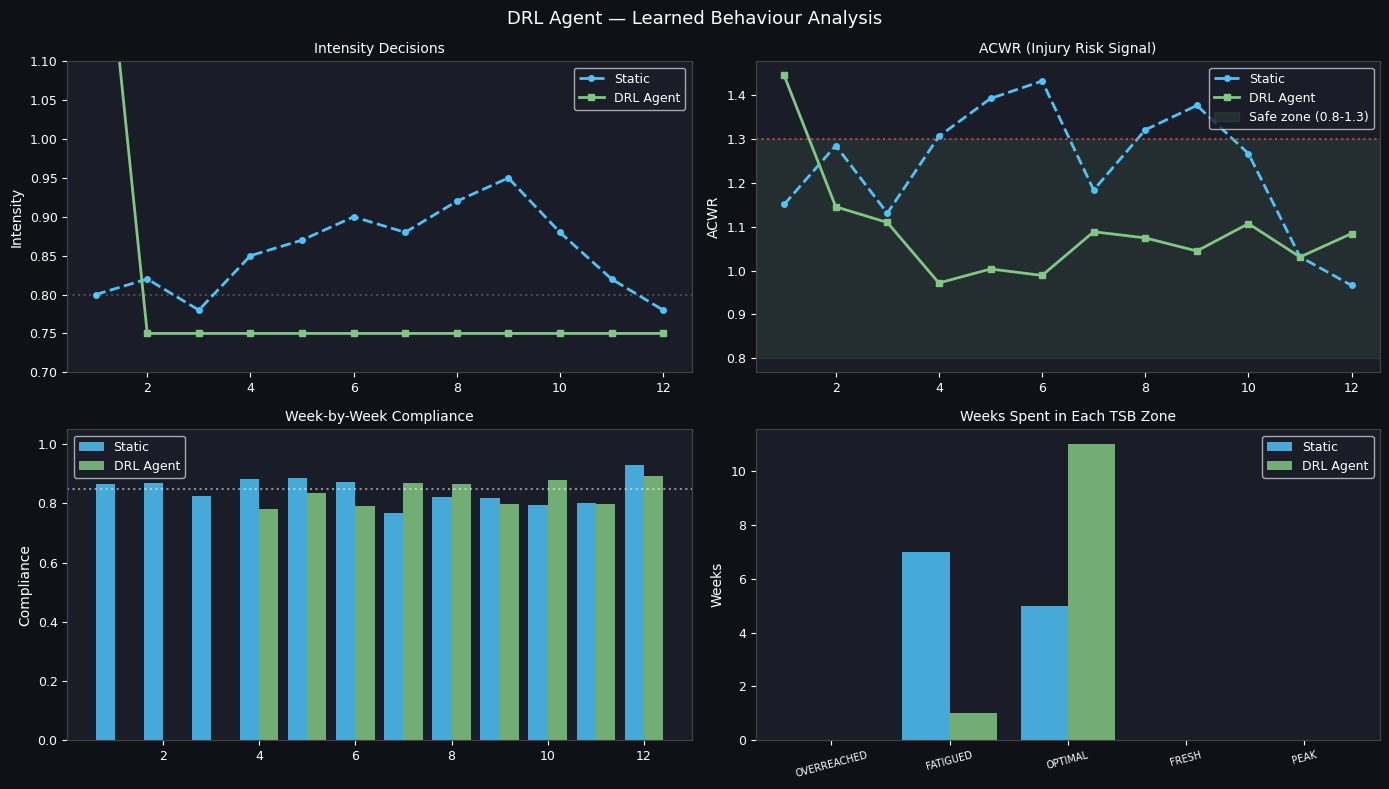

In [35]:
# ═══════════════════════════════════════════════════
# WHAT DID THE AGENT LEARN?
# Show the agent's decision patterns
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('DRL Agent — Learned Behaviour Analysis',
             color='white', fontsize=13)

for ax in axes.flat:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[:].set_color('#444')

d_hist = results["Intermediate"]["drl"]["history"]
s_hist = results["Intermediate"]["static"]["history"]
weeks  = [h["week"] for h in d_hist]

# Panel 1: Intensity comparison
axes[0,0].plot(weeks, [h["intensity"] for h in s_hist],
               color=STATIC, linewidth=2, marker='o', markersize=4,
               label='Static', linestyle='--')
axes[0,0].plot(weeks, [h["intensity"] for h in d_hist],
               color=DRL, linewidth=2, marker='s', markersize=4,
               label='DRL Agent')
axes[0,0].axhline(y=0.80, color='white', alpha=0.2, linestyle=':')
axes[0,0].set_title('Intensity Decisions', color='white', fontsize=10)
axes[0,0].set_ylabel('Intensity', color='white')
axes[0,0].set_ylim(0.7, 1.1)
axes[0,0].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Panel 2: ACWR over time
axes[0,1].plot(weeks, [h["acwr"] for h in s_hist],
               color=STATIC, linewidth=2, marker='o', markersize=4,
               label='Static', linestyle='--')
axes[0,1].plot(weeks, [h["acwr"] for h in d_hist],
               color=DRL, linewidth=2, marker='s', markersize=4,
               label='DRL Agent')
axes[0,1].axhspan(0.8, 1.3, alpha=0.1, color='#81c784', label='Safe zone (0.8-1.3)')
axes[0,1].axhline(y=1.3, color='#ef5350', linestyle=':', alpha=0.7)
axes[0,1].set_title('ACWR (Injury Risk Signal)', color='white', fontsize=10)
axes[0,1].set_ylabel('ACWR', color='white')
axes[0,1].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Panel 3: Week-by-week compliance
axes[1,0].bar(np.array(weeks)-0.2,
              [h["compliance"] for h in s_hist],
              0.4, color=STATIC, alpha=0.85, label='Static')
axes[1,0].bar(np.array(weeks)+0.2,
              [h["compliance"] for h in d_hist],
              0.4, color=DRL, alpha=0.85, label='DRL Agent')
axes[1,0].axhline(y=0.85, color='white', linestyle=':', alpha=0.5)
axes[1,0].set_title('Week-by-Week Compliance', color='white', fontsize=10)
axes[1,0].set_ylabel('Compliance', color='white')
axes[1,0].set_ylim(0, 1.05)
axes[1,0].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Panel 4: TSB zone distribution
zone_order  = ['OVERREACHED','FATIGUED','OPTIMAL','FRESH','PEAK']
zone_colors = ['#ef5350','#ffb74d','#4fc3f7','#81c784','#ffd700']

s_zones = [h["tsb_zone"] for h in s_hist]
d_zones = [h["tsb_zone"] for h in d_hist]

s_counts = [s_zones.count(z) for z in zone_order]
d_counts = [d_zones.count(z) for z in zone_order]
x3 = np.arange(len(zone_order))

axes[1,1].bar(x3-0.2, s_counts, 0.4, color=STATIC, alpha=0.85, label='Static')
axes[1,1].bar(x3+0.2, d_counts, 0.4, color=DRL,    alpha=0.85, label='DRL Agent')
axes[1,1].set_xticks(x3)
axes[1,1].set_xticklabels(zone_order, color='white', fontsize=7, rotation=15)
axes[1,1].set_title('Weeks Spent in Each TSB Zone', color='white', fontsize=10)
axes[1,1].set_ylabel('Weeks', color='white')
axes[1,1].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('agent_behaviour.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [39]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
_0 = user_secrets.get_secret("STRAVA_ACCESS_TOKEN")
_1 = user_secrets.get_secret("STRAVA_CLIENT_ID")
_2 = user_secrets.get_secret("STRAVA_CLIENT_SECRET")
_3 = user_secrets.get_secret("STRAVA_REFRESH_TOKEN")

print(_0, _1, _2, _3)

bc2f6cda76b57998fdd466e0df3a948401801ca0 118833 54d442bcf3419c770112b8c9fa52550da5513a00 e3494acb9a0b7a60862c960599644e61373ed8c0


In [40]:
!pip install requests --quiet

import requests
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()


CLIENT_ID     = user_secrets.get_secret("STRAVA_CLIENT_ID")       # ← paste yours
CLIENT_SECRET = user_secrets.get_secret("STRAVA_CLIENT_SECRET")   # ← paste yours
CODE          = secret_value_3 = user_secrets.get_secret("STRAVA_CODE")  # ← paste from redirect URL

response = requests.post(
    "https://www.strava.com/oauth/token",
    data={
        "client_id":     CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "code":          CODE,
        "grant_type":    "authorization_code",
    }
)

tokens = response.json()
print("Access token :", tokens.get("access_token"))
print("Refresh token:", tokens.get("refresh_token"))
print("Expires at   :", tokens.get("expires_at"))

# Save these — you'll use access_token below
ACCESS_TOKEN  = tokens.get("access_token")
REFRESH_TOKEN = tokens.get("refresh_token")

Access token : ae410a2ea7bbc31a1e6f27efeba28964c9ee6f4f
Refresh token: e3494acb9a0b7a60862c960599644e61373ed8c0
Expires at   : 1779222042


In [41]:
# ═══════════════════════════════════════════════════
# PULL STRAVA ACTIVITIES — last 16 weeks
# ═══════════════════════════════════════════════════

import requests
import pandas as pd
from datetime import datetime, timedelta
import numpy as np


def get_strava_activities(access_token: str,
                          weeks_back: int = 16) -> list:
    """
    Pull all activities from the last N weeks.
    Returns list of activity dicts.
    """
    after_ts = int((datetime.now() - timedelta(weeks=weeks_back)).timestamp())

    activities = []
    page       = 1

    while True:
        response = requests.get(
            "https://www.strava.com/api/v3/athlete/activities",
            headers={"Authorization": f"Bearer {access_token}"},
            params={
                "after":    after_ts,
                "per_page": 100,
                "page":     page,
            }
        )

        if response.status_code != 200:
            print(f"Error: {response.status_code} — {response.text}")
            break

        batch = response.json()
        if not batch:
            break

        activities.extend(batch)
        page += 1
        print(f"  Fetched page {page-1}: {len(batch)} activities")

    return activities


def filter_runs(activities: list) -> list:
    """Keep only running activities."""
    return [a for a in activities
            if a.get("type") == "Run" or
               a.get("sport_type") == "Run"]


print("Fetching your Strava activities...")
all_activities = get_strava_activities(ACCESS_TOKEN, weeks_back=16)
runs           = filter_runs(all_activities)

print(f"\n✅ Fetched {len(all_activities)} total activities")
print(f"   Running activities: {len(runs)}")
print()

# Preview
if runs:
    print("Most recent runs:")
    for r in runs[:5]:
        date     = r["start_date_local"][:10]
        dist_km  = r["distance"] / 1000
        duration = r["moving_time"] / 60
        hr       = r.get("average_heartrate", "N/A")
        print(f"  {date}  {dist_km:.1f}km  {duration:.0f}min  "
              f"HR:{hr}")

Fetching your Strava activities...
  Fetched page 1: 84 activities

✅ Fetched 84 total activities
   Running activities: 57

Most recent runs:
  2026-01-28  11.8km  79min  HR:136.3
  2026-01-29  11.6km  58min  HR:157.0
  2026-02-01  25.0km  136min  HR:155.3
  2026-02-03  10.3km  56min  HR:148.1
  2026-02-04  11.2km  75min  HR:140.4


✅ Your current physiological state (from Strava data):
   ATL (Fatigue) : 35.3
   CTL (Fitness) : 41.9
   TSB (Form)    : +6.7
   TSB Zone      : OPTIMAL



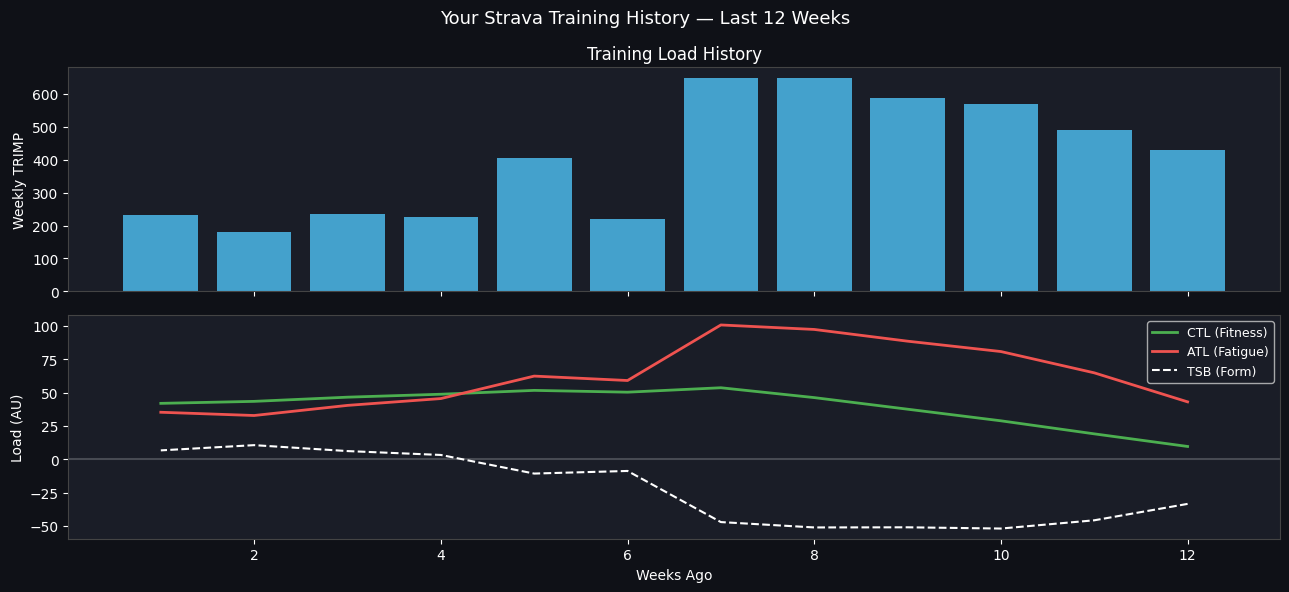

In [42]:
# ═══════════════════════════════════════════════════
# CONVERT STRAVA DATA → PHYSIOLOGICAL STATE
# This is the bridge between real data and the model
# ═══════════════════════════════════════════════════

def activities_to_weekly_trimp(runs: list,
                                weeks_back: int = 12) -> list:
    """
    Group runs by week and compute weekly TRIMP.
    Returns list of weekly TRIMP values (oldest first).
    """
    now       = datetime.now()
    week_data = {}

    for run in runs:
        date     = datetime.strptime(
            run["start_date_local"][:10], "%Y-%m-%d")
        weeks_ago = (now - date).days // 7

        if weeks_ago >= weeks_back:
            continue

        week_key = weeks_ago
        if week_key not in week_data:
            week_data[week_key] = []

        # Compute TRIMP for this run
        duration_min = run["moving_time"] / 60
        avg_hr       = run.get("average_heartrate")
        distance_km  = run["distance"] / 1000

        if avg_hr and avg_hr > 0:
            trimp = compute_trimp(
                duration_min, avg_hr=avg_hr,
                hr_max=190, hr_rest=55)
        else:
            # Fallback: estimate from pace
            if duration_min > 0 and distance_km > 0:
                pace_min_km = duration_min / distance_km
                rpe_estimate = max(3, min(9, 12 - pace_min_km))
                trimp = compute_trimp(duration_min, rpe=rpe_estimate)
            else:
                trimp = 0.0

        week_data[week_key].append(trimp)

    # Sum TRIMP per week, fill missing weeks with 0
    weekly_trimp = []
    for w in range(weeks_back - 1, -1, -1):
        week_trimp = sum(week_data.get(w, []))
        weekly_trimp.append(week_trimp)

    return weekly_trimp


def compute_current_state(weekly_trimp: list,
                           days_to_race: int = 84) -> PhysiologicalState:
    """
    Run Banister model over activity history to compute
    current ATL, CTL, TSB from real training data.
    """
    model = BannisterModel()
    model.reset()

    # Distribute weekly TRIMP across 7 days
    for weekly_t in weekly_trimp:
        # Simple distribution: rest Mon, 6 days of running
        fracs = np.array([0.0, 0.15, 0.12, 0.20, 0.12, 0.15, 0.26])
        daily = (fracs * weekly_t).tolist()
        for t in daily:
            model.update_day(t)

    return PhysiologicalState(
        atl=model.atl,
        ctl=model.ctl,
        tsb=model.ctl - model.atl,
        ramp_rate=0.0,
        rpe_avg=5.0,
        compliance=0.85,
        injury_flag=0,
        days_to_race=days_to_race,
    )


# ── Compute your current state ────────────────────────────────────
weekly_trimp  = activities_to_weekly_trimp(runs, weeks_back=12)
current_state = compute_current_state(weekly_trimp, days_to_race=84)

print("✅ Your current physiological state (from Strava data):")
print(f"   ATL (Fatigue) : {current_state.atl:.1f}")
print(f"   CTL (Fitness) : {current_state.ctl:.1f}")
print(f"   TSB (Form)    : {current_state.tsb:+.1f}")
print(f"   TSB Zone      : {BannisterModel().get_tsb_zone()}")
print()

# Visualise your training history
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Your Strava Training History — Last 12 Weeks',
             color='white', fontsize=13)

for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')

weeks_ago = list(range(12, 0, -1))
ax1.bar(weeks_ago, weekly_trimp, color='#4fc3f7', alpha=0.8)
ax1.set_ylabel('Weekly TRIMP', color='white')
ax1.set_title('Training Load History', color='white')

# Recompute day-by-day for the chart
m = BannisterModel()
m.reset()
atls, ctls, tsbs = [], [], []
for wt in weekly_trimp:
    fracs = np.array([0.0, 0.15, 0.12, 0.20, 0.12, 0.15, 0.26])
    for t in (fracs * wt).tolist():
        m.update_day(t)
    atls.append(m.atl)
    ctls.append(m.ctl)
    tsbs.append(m.tsb)

ax2.plot(weeks_ago, ctls, color='#4CAF50', linewidth=2, label='CTL (Fitness)')
ax2.plot(weeks_ago, atls, color='#ef5350', linewidth=2, label='ATL (Fatigue)')
ax2.plot(weeks_ago, tsbs, color='white',   linewidth=1.5,
         linestyle='--', label='TSB (Form)')
ax2.axhline(y=0, color='white', alpha=0.2)
ax2.set_ylabel('Load (AU)', color='white')
ax2.set_xlabel('Weeks Ago', color='white')
ax2.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
# ═══════════════════════════════════════════════════
# BUILD YOUR PERSONAL ATHLETE PROFILE
# Derived from your actual Strava data
# ═══════════════════════════════════════════════════

def build_personal_profile(runs: list,
                            current_state: PhysiologicalState,
                            days_to_race: int = 84) -> AthleteProfile:
    """
    Build an AthleteProfile personalised to your Strava data.
    Estimates max weekly km, compliance tendency, and fitness level.
    """
    if not runs:
        return AthleteProfile.intermediate()

    # Max weekly volume from last 12 weeks
    weekly_trimp = activities_to_weekly_trimp(runs, weeks_back=12)
    weekly_km    = []

    now = datetime.now()
    week_km_data = {}
    for run in runs:
        date     = datetime.strptime(run["start_date_local"][:10], "%Y-%m-%d")
        weeks_ago = (now - date).days // 7
        if weeks_ago < 12:
            week_km_data.setdefault(weeks_ago, 0)
            week_km_data[weeks_ago] += run["distance"] / 1000

    all_weekly_km = list(week_km_data.values())
    if all_weekly_km:
        max_recent_km = max(all_weekly_km)
        avg_weekly_km = np.mean(all_weekly_km)
    else:
        max_recent_km = 40.0
        avg_weekly_km = 30.0

    # Estimate max weekly km as 120% of recent peak
    estimated_max = min(max_recent_km * 1.2, 120.0)
    estimated_max = max(estimated_max, 30.0)

    # Classify athlete level from CTL
    ctl = current_state.ctl
    if ctl < 25:
        injury_susceptibility = 0.55
        base_compliance       = 0.78
    elif ctl < 45:
        injury_susceptibility = 0.40
        base_compliance       = 0.85
    else:
        injury_susceptibility = 0.28
        base_compliance       = 0.90

    profile = AthleteProfile(
        initial_ctl           = current_state.ctl,
        initial_atl           = current_state.atl,
        max_weekly_km         = estimated_max,
        min_weekly_km         = max(estimated_max * 0.35, 20.0),
        injury_susceptibility = injury_susceptibility,
        base_compliance       = base_compliance,
        days_to_race          = days_to_race,
    )

    print(f"✅ Your personal athlete profile:")
    print(f"   Initial CTL        : {profile.initial_ctl:.1f}")
    print(f"   Initial ATL        : {profile.initial_atl:.1f}")
    print(f"   Max weekly km      : {profile.max_weekly_km:.0f} km")
    print(f"   Min weekly km      : {profile.min_weekly_km:.0f} km")
    print(f"   Injury susceptibility: {profile.injury_susceptibility:.0%}")
    print(f"   Base compliance    : {profile.base_compliance:.0%}")
    print(f"   Race in            : {days_to_race} days")

    return profile


DAYS_TO_RACE   = 84    # ← change this to your actual race countdown
personal_profile = build_personal_profile(
    runs, current_state, days_to_race=DAYS_TO_RACE)

✅ Your personal athlete profile:
   Initial CTL        : 41.9
   Initial ATL        : 35.3
   Max weekly km      : 89 km
   Min weekly km      : 31 km
   Injury susceptibility: 40%
   Base compliance    : 85%
   Race in            : 84 days


In [44]:
# ═══════════════════════════════════════════════════
# GENERATE YOUR PERSONAL 12-WEEK PLAN
# DRL agent prescribes based on YOUR current state
# ═══════════════════════════════════════════════════

def generate_personal_plan(model, profile: AthleteProfile) -> list:
    """Run the DRL agent with your personal profile."""
    env = AthleteEnvWithHistory(
        profile_type="intermediate", max_weeks=12, seed=42)
    env.base_env.profile          = profile
    env.base_env.profile.days_to_race = profile.days_to_race
    env.base_env.sim              = AthleteSimulator(profile, seed=42)

    obs, _ = env.reset()
    plan   = []
    terminated = truncated = False

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        state = env.base_env._history[-1]["state"]

        # Translate action to human-readable plan
        intensity = float(action[0])
        volume    = float(action[1])
        dist      = float(action[2])

        if intensity < 0.80:       int_label = "Recovery / Easy Aerobic"
        elif intensity < 0.87:     int_label = "Moderate Aerobic"
        elif intensity < 0.93:     int_label = "Threshold / Tempo"
        else:                      int_label = "Race Pace / VO2max"

        if dist < 0.25:    session_mix = "Easy runs + long run"
        elif dist < 0.50:  session_mix = "Easy + 1 tempo + long run"
        elif dist < 0.75:  session_mix = "Easy + 2 quality + long run"
        else:              session_mix = "Easy + intervals + tempo + long"

        plan.append({
            "week":        info["week"],
            "volume_km":   volume,
            "actual_km":   info["actual_km"],
            "intensity":   intensity,
            "int_label":   int_label,
            "session_mix": session_mix,
            "ctl":         state.ctl,
            "tsb":         state.tsb,
            "zone":        info["tsb_zone"],
            "acwr":        info["acwr"],
            "reward":      reward,
        })

    return plan


personal_plan = generate_personal_plan(model, personal_profile)

print("="*72)
print("  YOUR PERSONALISED 12-WEEK TRAINING PLAN")
print(f"  Generated by DRL Agent — based on your Strava history")
print("="*72)
print(f"\n  {'Wk':>2}  {'Volume':>8}  {'Type':>22}  "
      f"{'Session Mix':>28}  {'CTL':>5}  {'Zone'}")
print("  " + "─"*90)

for w in personal_plan:
    print(f"  {w['week']:>2}  "
          f"{w['volume_km']:>6.0f}km  "
          f"{w['int_label']:>22}  "
          f"{w['session_mix']:>28}  "
          f"{w['ctl']:>5.1f}  "
          f"{w['zone']}")

final = personal_plan[-1]
print(f"\n  Final CTL : {final['ctl']:.1f}")
print(f"  Final TSB : {final['tsb']:+.1f}  (target: +5 to +25 on race day)")

  YOUR PERSONALISED 12-WEEK TRAINING PLAN
  Generated by DRL Agent — based on your Strava history

  Wk    Volume                    Type                   Session Mix    CTL  Zone
  ──────────────────────────────────────────────────────────────────────────────────────────
   1      56km      Race Pace / VO2max          Easy runs + long run   48.7  FATIGUED
   2      35km  Recovery / Easy Aerobic          Easy runs + long run   47.5  OPTIMAL
   3      35km  Recovery / Easy Aerobic          Easy runs + long run   45.5  OPTIMAL
   4      35km  Recovery / Easy Aerobic          Easy runs + long run   44.6  OPTIMAL
   5      35km  Recovery / Easy Aerobic          Easy runs + long run   42.9  OPTIMAL
   6      35km  Recovery / Easy Aerobic          Easy runs + long run   42.2  OPTIMAL
   7      35km  Recovery / Easy Aerobic          Easy runs + long run   42.9  OPTIMAL
   8      35km  Recovery / Easy Aerobic          Easy runs + long run   42.6  OPTIMAL
   9      35km  Recovery / Easy Aerobi

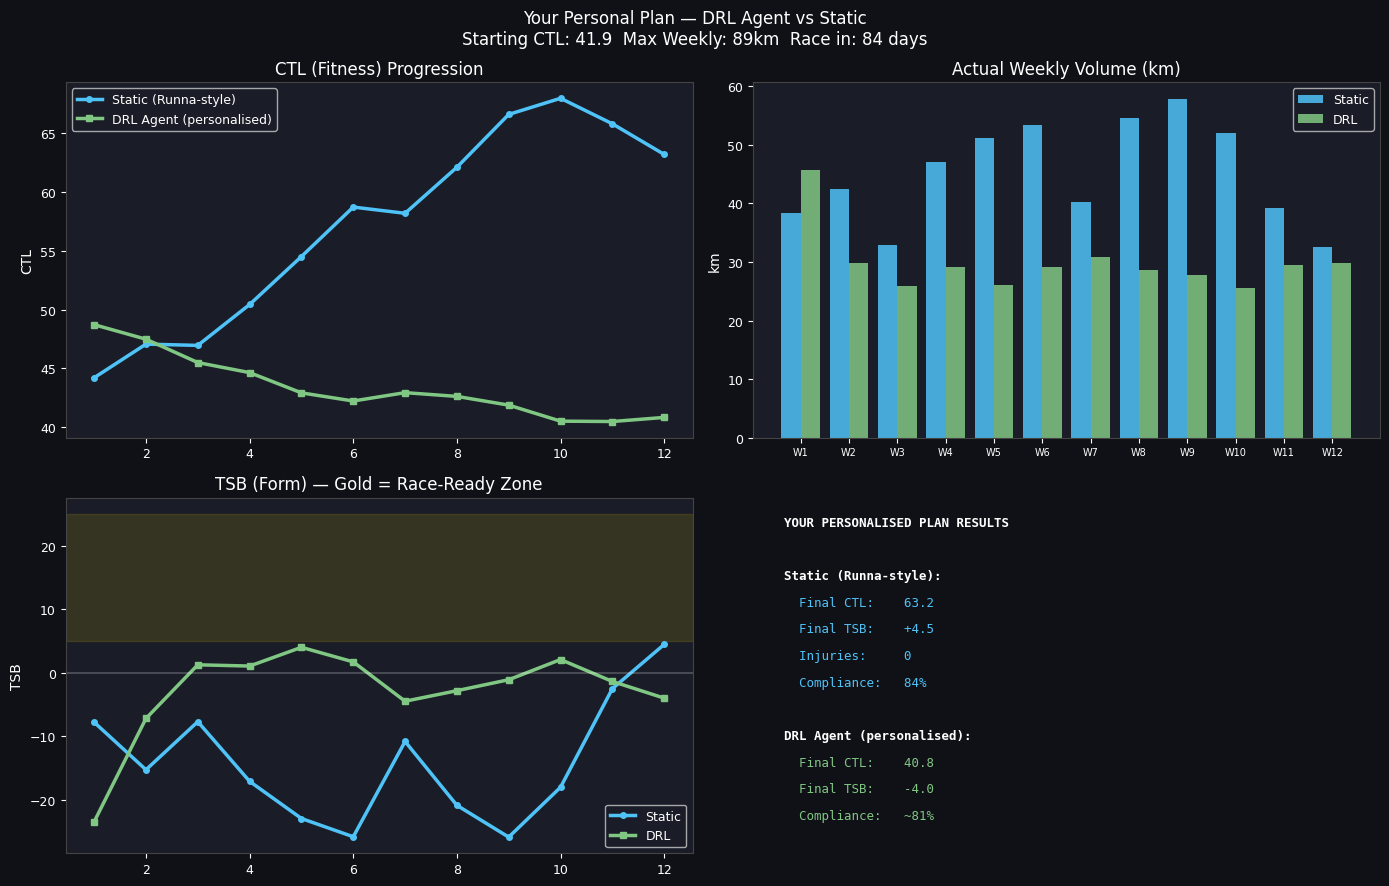

✅ Chart saved → your_personal_plan.png

  This chart shows what YOUR 12-week plan looks like
  based on your actual Strava training history.
  This is Notebook 4's core output — personalised coaching.


In [45]:
# ═══════════════════════════════════════════════════
# COMPARISON — YOUR DRL PLAN vs STATIC RUNNA-STYLE PLAN
# This is the personalised version of Notebook 3
# ═══════════════════════════════════════════════════

static_plan_personal = run_static_plan(personal_profile, seed=42)
s_hist = static_plan_personal["history"]
d_hist = personal_plan

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#0f1117')
fig.suptitle(f'Your Personal Plan — DRL Agent vs Static\n'
             f'Starting CTL: {personal_profile.initial_ctl:.1f}  '
             f'Max Weekly: {personal_profile.max_weekly_km:.0f}km  '
             f'Race in: {DAYS_TO_RACE} days',
             color='white', fontsize=12)

STATIC = '#4fc3f7'
DRL    = '#81c784'
weeks  = [h["week"] for h in s_hist]

for ax in axes.flat:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[:].set_color('#444')

# CTL progression
axes[0,0].plot(weeks, [h["ctl"] for h in s_hist],
               color=STATIC, linewidth=2.5, marker='o', markersize=4,
               label='Static (Runna-style)')
axes[0,0].plot([w["week"] for w in d_hist],
               [w["ctl"] for w in d_hist],
               color=DRL, linewidth=2.5, marker='s', markersize=4,
               label='DRL Agent (personalised)')
axes[0,0].set_title('CTL (Fitness) Progression', color='white')
axes[0,0].set_ylabel('CTL', color='white')
axes[0,0].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Weekly volume
x = np.arange(len(weeks))
axes[0,1].bar(x-0.2, [h["actual_km"] for h in s_hist],
              0.4, color=STATIC, alpha=0.85, label='Static')
axes[0,1].bar(x+0.2, [w["actual_km"] for w in d_hist],
              0.4, color=DRL, alpha=0.85, label='DRL')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels([f'W{i}' for i in weeks], fontsize=7, color='white')
axes[0,1].set_title('Actual Weekly Volume (km)', color='white')
axes[0,1].set_ylabel('km', color='white')
axes[0,1].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# TSB
axes[1,0].plot(weeks, [h["tsb"] for h in s_hist],
               color=STATIC, linewidth=2.5, marker='o', markersize=4,
               label='Static')
axes[1,0].plot([w["week"] for w in d_hist],
               [w["tsb"] for w in d_hist],
               color=DRL, linewidth=2.5, marker='s', markersize=4,
               label='DRL')
axes[1,0].axhspan(5, 25, alpha=0.12, color='gold')
axes[1,0].axhline(y=0, color='white', alpha=0.2)
axes[1,0].set_title('TSB (Form) — Gold = Race-Ready Zone', color='white')
axes[1,0].set_ylabel('TSB', color='white')
axes[1,0].legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)

# Summary scorecard
axes[1,1].axis('off')
s_res = static_plan_personal
d_final = personal_plan[-1]
d_compliance = np.mean([w.get("actual_km", 0) /
                         max(w["volume_km"], 1) for w in personal_plan])

scorecard_lines = [
    ("YOUR PERSONALISED PLAN RESULTS", None),
    ("", None),
    (f"Static (Runna-style):", None),
    (f"  Final CTL:    {s_res['final_ctl']:.1f}", STATIC),
    (f"  Final TSB:    {s_res['final_tsb']:+.1f}", STATIC),
    (f"  Injuries:     {s_res['total_injuries']:.0f}", STATIC),
    (f"  Compliance:   {s_res['avg_compliance']:.0%}", STATIC),
    ("", None),
    (f"DRL Agent (personalised):", None),
    (f"  Final CTL:    {d_final['ctl']:.1f}", DRL),
    (f"  Final TSB:    {d_final['tsb']:+.1f}", DRL),
    (f"  Compliance:   ~{d_compliance:.0%}", DRL),
]

for i, (line, color) in enumerate(scorecard_lines):
    col = color if color else 'white'
    wt  = 'bold' if color is None and line else 'normal'
    axes[1,1].text(0.05, 0.95 - i*0.075, line,
                   transform=axes[1,1].transAxes,
                   color=col, fontsize=9, va='top',
                   fontweight=wt, fontfamily='monospace')

plt.tight_layout()
plt.savefig('your_personal_plan.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("✅ Chart saved → your_personal_plan.png")
print()
print("  This chart shows what YOUR 12-week plan looks like")
print("  based on your actual Strava training history.")
print("  This is Notebook 4's core output — personalised coaching.")

In [46]:
# ═══════════════════════════════════════════════════
# EXPORT — shareable text version of your plan
# ═══════════════════════════════════════════════════

print("="*60)
print("  YOUR 12-WEEK PLAN — SHAREABLE VERSION")
print("="*60)
print(f"""
  Generated: {datetime.now().strftime('%B %d, %Y')}
  Method:    DRL Agent (PPO + Transformer)
  Data:      Your Strava activity history
  Race in:   {DAYS_TO_RACE} days

  PHASE BREAKDOWN
  ───────────────────────────────────────────────────
  Weeks 1-3:  Base building — easy aerobic foundation
  Weeks 4-8:  Progressive build — introduce quality sessions
  Weeks 9-10: Peak — highest load weeks
  Weeks 11-12: Taper — reduce volume, arrive fresh

  WEEK-BY-WEEK PLAN
  ───────────────────────────────────────────────────""")

for w in personal_plan:
    phase = ("BASE  " if w["week"] <= 3 else
             "BUILD " if w["week"] <= 8 else
             "PEAK  " if w["week"] <= 10 else
             "TAPER ")
    print(f"  Week {w['week']:2d} [{phase}]  "
          f"{w['volume_km']:.0f}km  {w['int_label']}")
    print(f"           Sessions: {w['session_mix']}")
    print(f"           CTL: {w['ctl']:.1f}  TSB: {w['tsb']:+.1f}  "
          f"Zone: {w['zone']}")
    print()

print("  ───────────────────────────────────────────────────")
print(f"  Race Week Target TSB: +5 to +25")
print(f"  Your projected TSB:   {personal_plan[-1]['tsb']:+.1f}")
print(f"  Your projected CTL:   {personal_plan[-1]['ctl']:.1f}")
print()
print("  This plan was generated using a Deep Reinforcement")
print("  Learning agent trained on a physiological simulator")
print("  (Banister 1991) and calibrated to your Strava data.")
print("="*60)

  YOUR 12-WEEK PLAN — SHAREABLE VERSION

  Generated: May 19, 2026
  Method:    DRL Agent (PPO + Transformer)
  Data:      Your Strava activity history
  Race in:   84 days

  PHASE BREAKDOWN
  ───────────────────────────────────────────────────
  Weeks 1-3:  Base building — easy aerobic foundation
  Weeks 4-8:  Progressive build — introduce quality sessions
  Weeks 9-10: Peak — highest load weeks
  Weeks 11-12: Taper — reduce volume, arrive fresh

  WEEK-BY-WEEK PLAN
  ───────────────────────────────────────────────────
  Week  1 [BASE  ]  56km  Race Pace / VO2max
           Sessions: Easy runs + long run
           CTL: 48.7  TSB: -23.4  Zone: FATIGUED

  Week  2 [BASE  ]  35km  Recovery / Easy Aerobic
           Sessions: Easy runs + long run
           CTL: 47.5  TSB: -7.2  Zone: OPTIMAL

  Week  3 [BASE  ]  35km  Recovery / Easy Aerobic
           Sessions: Easy runs + long run
           CTL: 45.5  TSB: +1.3  Zone: OPTIMAL

  Week  4 [BUILD ]  35km  Recovery / Easy Aerobic
      